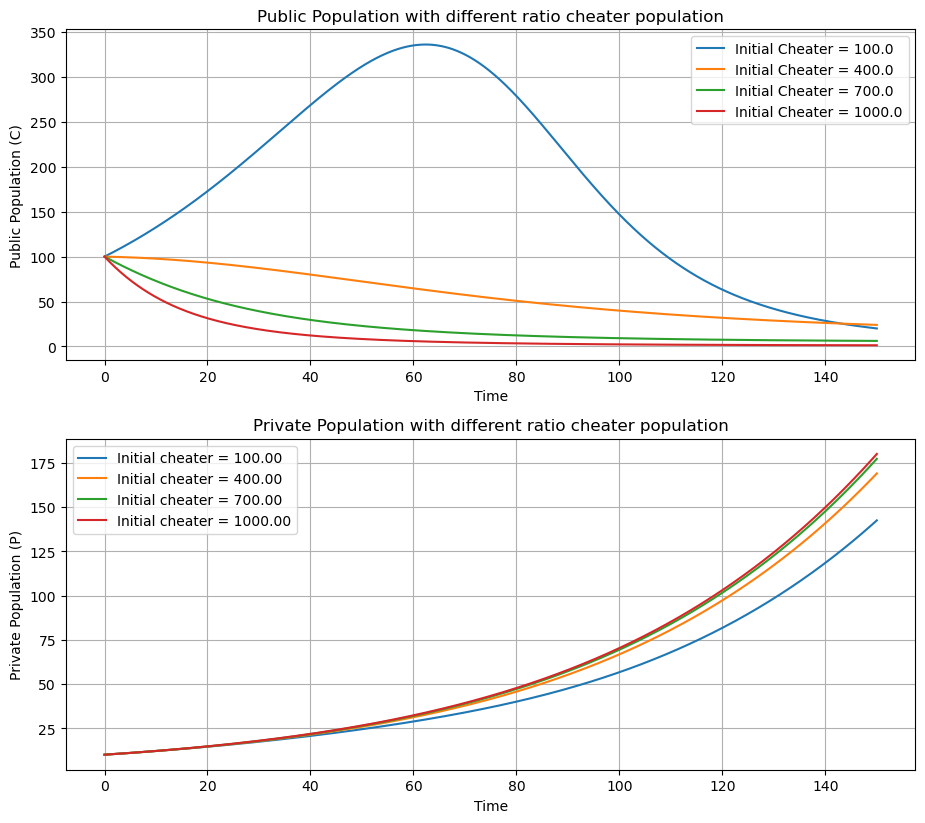

In [55]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Range of initial populations for defector
D_values = np.linspace(100, 1000, 4)  # D values from 0.1 to 10 (log scale for better spacing)

# Initial conditions
C0, P0 = 100.0, 10.0

# Time grid
t = np.linspace(0, 150, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, D0 in enumerate(D_values):
    y0 = C0, D0, P0  # Set initial conditions with varying D0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot time-series for C, D, and P
    plt.subplot(3, 2, 1)
    plt.plot(t, C, label=f'Initial Cheater = {D0:.1f}')
    plt.xlabel('Time')
    plt.ylabel('Public Population (C)')
    plt.title('Public Population with different ratio cheater population')
    plt.grid(True)

    plt.subplot(3, 2, 3)
    plt.plot(t, P, label=f'Initial cheater = {D0:.1f}')
    plt.xlabel('Time')
    plt.ylabel('Private Population (P)')
    plt.title('Private Population with different ratio cheater population')
    plt.grid(True)

# Add legends to the plots
plt.subplot(3, 2, 1)
plt.legend()
plt.subplot(3, 2, 3)
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# Define parameters
rc = 1.0    # Growth rate of public metabolizers
rp = 1.1    # Growth rate of private metabolizers
alpha = 0.5  # Cheaters' benefit from public metabolizers
beta = 0.3   # Competition between public and private metabolizers
eta = 0.4    # Effect of public metabolizers on private metabolizers
nu = 0.2     # Mortality rate of cheaters

# Define the steady-state equations to solve
def steady_state_eqs(vars, rc, rp, alpha, beta, eta, nu):
    C, D, P = vars
    eq1 = rc * C - alpha * C * D - beta * C * P
    eq2 = alpha * C * D - nu * D
    eq3 = rp * P - eta * P * C
    return [eq1, eq2, eq3]

# Initial guesses for the steady-state concentrations
initial_guess = [0.5, 0.2, 0.3]

# Solve for steady-state concentrations
C_star, D_star, P_star = fsolve(steady_state_eqs, initial_guess, args=(rc, rp, alpha, beta, eta, nu))

print(f"Steady-state concentrations:\nC* = {C_star}, D* = {D_star}, P* = {P_star}")

# Define a small perturbation for numerical derivative
delta = 1e-4

# Compute control coefficients for parameter 'alpha'
# Numerical derivative: C_alpha^C = (C*(alpha + delta) - C*) / (delta * alpha)

# Perturb 'alpha' and compute new steady-state concentrations
def compute_control_coefficients(param, param_name):
    param_perturbed = param + delta
    
    # Solve the steady state with the perturbed parameter
    if param_name == 'alpha':
        new_C_star, new_D_star, new_P_star = fsolve(steady_state_eqs, initial_guess, args=(rc, rp, param_perturbed, beta, eta, nu))
    elif param_name == 'rc':
        new_C_star, new_D_star, new_P_star = fsolve(steady_state_eqs, initial_guess, args=(param_perturbed, rp, alpha, beta, eta, nu))
    elif param_name == 'beta':
        new_C_star, new_D_star, new_P_star = fsolve(steady_state_eqs, initial_guess, args=(rc, rp, alpha, param_perturbed, eta, nu))
    # Add more parameters if needed
    
    # Compute the control coefficients
    C_alpha_C = (new_C_star - C_star) / (delta * param) * param / C_star
    C_alpha_D = (new_D_star - D_star) / (delta * param) * param / D_star
    C_alpha_P = (new_P_star - P_star) / (delta * param) * param / P_star
    
    return C_alpha_C, C_alpha_D, C_alpha_P

# Example: Control coefficients with respect to 'alpha'
C_alpha_C, C_alpha_D, C_alpha_P = compute_control_coefficients(alpha, 'alpha')
print(f"Control Coefficients for 'alpha':\nC_alpha^C = {C_alpha_C}, C_alpha^D = {C_alpha_D}, C_alpha^P = {C_alpha_P}")


Steady-state concentrations:
C* = 0.4000000000022512, D* = 2.0000000000118012, P* = -1.3213613804036187e-13
Control Coefficients for 'alpha':
C_alpha^C = -1.9996001817372415, C_alpha^D = -1.9996001866777442, C_alpha^P = -18127.26036604944


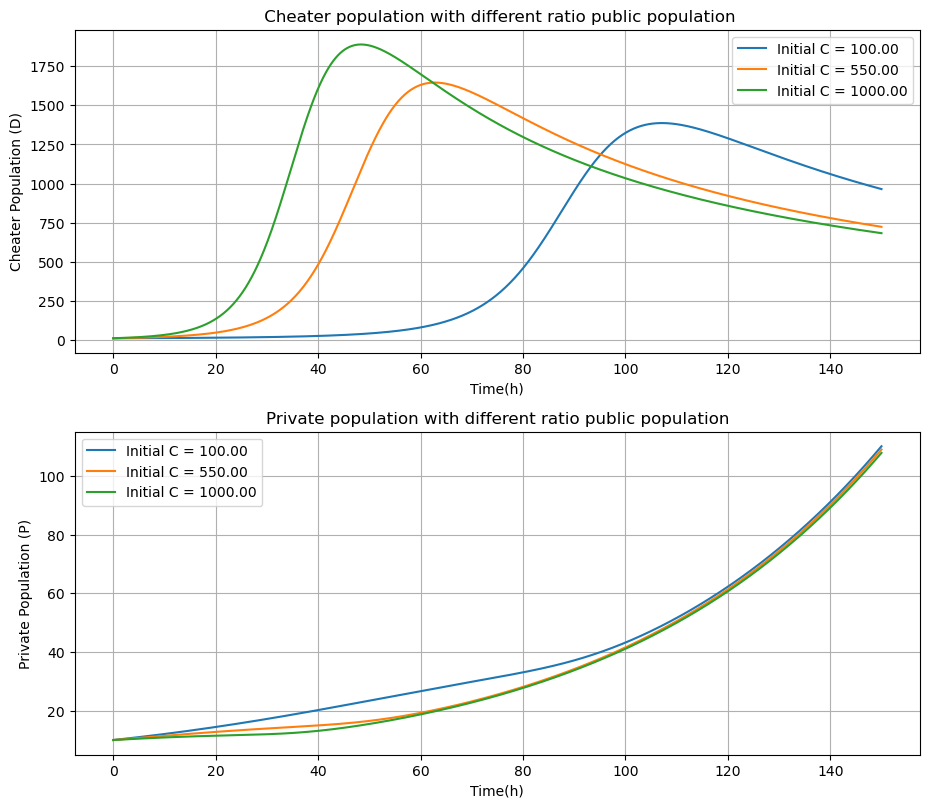

In [51]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Fixed initial population for cheater (defector) and private
D0 = 10.0
P0 = 10.0

# Range of initial populations for cooperators (C)
C_values = np.linspace(100, 1000, 3)  # C values from 50 to 150

# Time grid
t = np.linspace(0, 150, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, C0 in enumerate(C_values):
    y0 = C0, D0, P0  # Set initial conditions with varying C0 and fixed D0, P0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T


    plt.subplot(3, 2, 3)
    plt.plot(t, D, label=f'Initial P = {C0:.2f}')
    plt.xlabel('Time(h)')
    plt.ylabel('Cheater Population (D)')
    plt.title(' Cheater population with different ratio public population')
    plt.grid(True)

    plt.subplot(3, 2, 5)
    plt.plot(t, P, label=f'Initial C = {C0:.2f}')
    plt.xlabel('Time(h)')
    plt.ylabel('Private Population (P)')
    plt.title('Private population with different ratio public population')
    plt.grid(True)

# Add legends to the plots
plt.subplot(3, 2, 3)
plt.legend()
plt.subplot(3, 2, 5)
plt.legend()

plt.tight_layout()
plt.show()


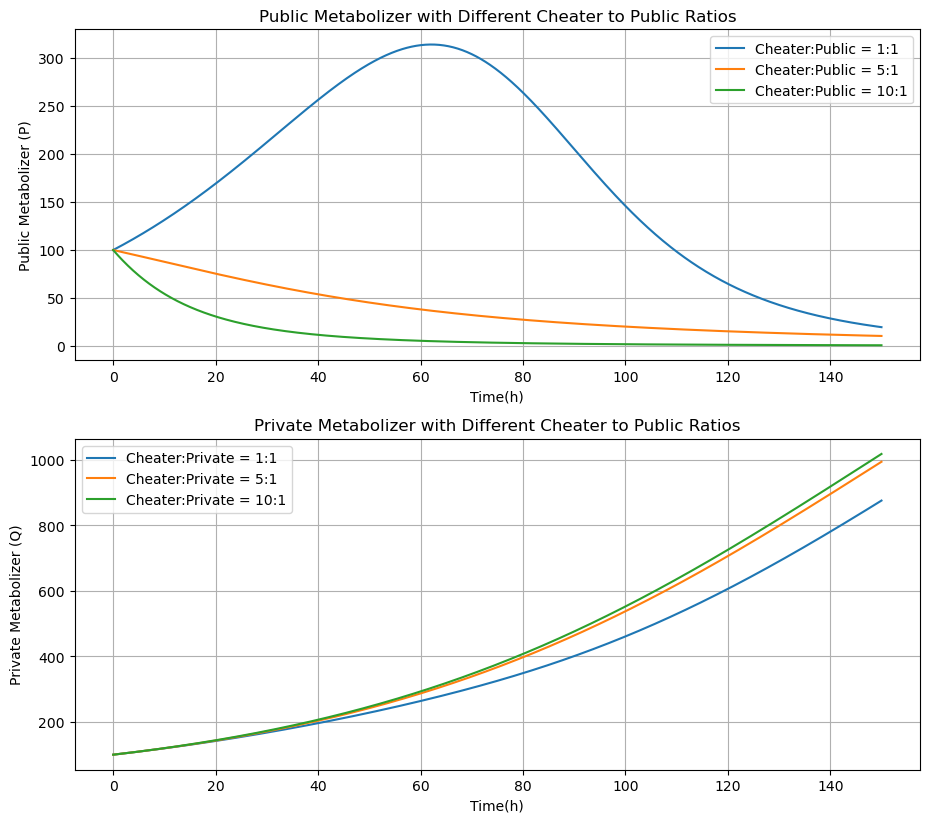

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Range of cheater to public population ratios
ratios = [1, 5, 10]  # D/C ratios (cheater to public ratio)

# Initial conditions
C0 = 100.0  # Initial public population (C)
P0 = 100.0   # Initial private population (P)

# Time grid
t = np.linspace(0, 150, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, ratio in enumerate(ratios):
    D0 = C0 * ratio  # Set the initial cheater population based on ratio (D0 = C0 * ratio)
    y0 = C0, D0, P0  # Initial conditions: C0, D0, P0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot time-series for public population (C)
    plt.subplot(3, 2, 1)
    plt.plot(t, C, label=f'Cheater:Public = {int(ratio)}:1')
    plt.xlabel('Time(h)')
    plt.ylabel('Public Metabolizer (P)')
    plt.title('Public Metabolizer with Different Cheater to Public Ratios')
    plt.grid(True)

    # Plot time-series for private population (P)
    plt.subplot(3, 2, 3)
    plt.plot(t, P, label=f'Cheater:Private = {int(ratio)}:1')
    plt.xlabel('Time(h)')
    plt.ylabel('Private Metabolizer (Q)')
    plt.title('Private Metabolizer with Different Cheater to Public Ratios')
    plt.grid(True)

# Add legends to the plots
plt.subplot(3, 2, 1)
plt.legend()
plt.subplot(3, 2, 3)
plt.legend()

plt.tight_layout()
plt.show()


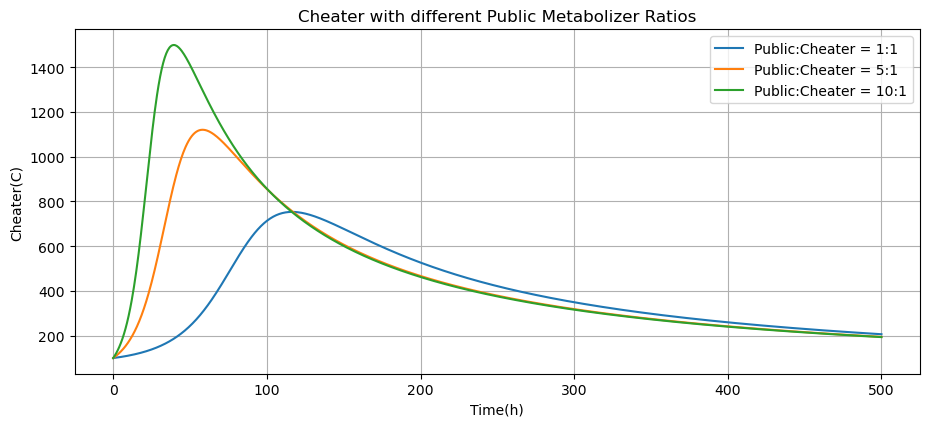

In [4]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
beta = 0.00001  # benefit from cooperator to private
gamma = 0.00001  # cost spent by private population
alpha = 0.0001  # benefit from cooperator to defector
mu = 0.04  # growth rate (benefit) of cooperator
eta = 0.02  # growth rate (benefit) of private
nu = 0.00001  # transportation cost of defector

# Range of public to cheater population ratios
ratios = [1, 5, 10]  # C/D ratios (public to cheater ratio)

# Initial conditions
D0 = 100.0  # Constant initial cheater population (D)
P0 = 100.0   # Initial private population (P)

# Time grid
t = np.linspace(0, 500, 1000)

# Create a figure
plt.figure(figsize=(18, 12))

for i, ratio in enumerate(ratios):
    C0 = D0 * ratio  # Set the initial public population based on the ratio (C0 = D0 * ratio)
    y0 = C0, D0, P0  # Initial conditions: C0, D0, P0

    # Integrate the equations over the time grid, t
    ret = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
    C, D, P = ret.T

    # Plot time-series for public population (C)
    plt.subplot(3, 2, 1)
    plt.plot(t, D, label=f'Public:Cheater = {int(ratio)}:1')
    plt.xlabel('Time(h)')
    plt.ylabel('Cheater(C)')
    plt.title('Cheater with different Public Metabolizer Ratios')
    plt.grid(True)


# Add legends to the plots
plt.subplot(3, 2, 1)
plt.legend()

plt.tight_layout()
plt.show()


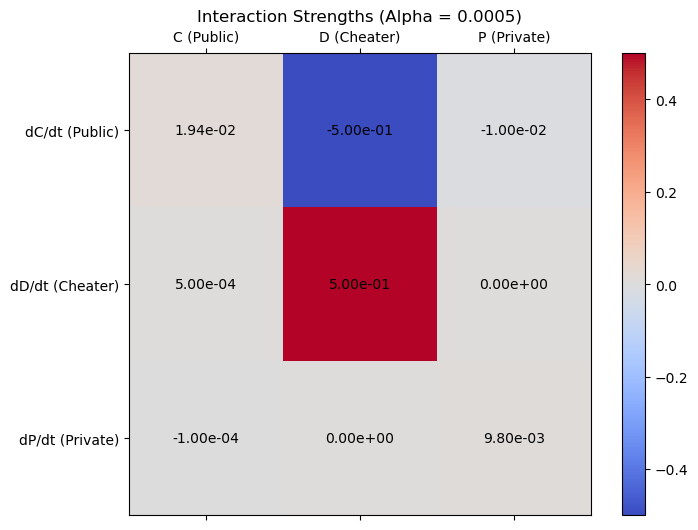

In [5]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Numerical differentiation function (finite differences)
def compute_interaction_strengths(C0, D0, P0, nu, beta, alpha, mu, gamma, eta, eps=1e-6):
    y0 = np.array([C0, D0, P0])
    t = 0  # We evaluate at an initial time
    base_rates = np.array(deriv(y0, t, nu, beta, alpha, mu, gamma, eta))
    
    interaction_matrix = np.zeros((3, 3))  # 3 populations (C, D, P) by 3 growth rates (dC, dD, dP)
    
    for i in range(3):
        perturbed_y = y0.copy()
        perturbed_y[i] += eps
        perturbed_rates = np.array(deriv(perturbed_y, t, nu, beta, alpha, mu, gamma, eta))
        interaction_matrix[:, i] = (perturbed_rates - base_rates) / eps  # Numerical derivative
        
    return interaction_matrix

# Parameters
beta = 0.00001
gamma = 0.00001
mu = 0.04
eta = 0.02
nu = 0.00001

# Initial conditions
C0, D0, P0 = 1000.0, 1.0, 10.0
alpha = 0.0005  # Chosen alpha value for heatmap

# Compute interaction strengths
interaction_matrix = compute_interaction_strengths(C0, D0, P0, nu, beta, alpha, mu, gamma, eta)

# Plot heatmap using matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(interaction_matrix, cmap='coolwarm')

# Add color bar
plt.colorbar(cax)

# Set ticks and labels
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['C (Public)', 'D (Cheater)', 'P (Private)'])
ax.set_yticklabels(['dC/dt (Public)', 'dD/dt (Cheater)', 'dP/dt (Private)'])

# Add interaction strength values on the heatmap
for (i, j), val in np.ndenumerate(interaction_matrix):
    ax.text(j, i, f'{val:.2e}', ha='center', va='center', color='black')

plt.title(f'Interaction Strengths (Alpha = {alpha})')
plt.show()


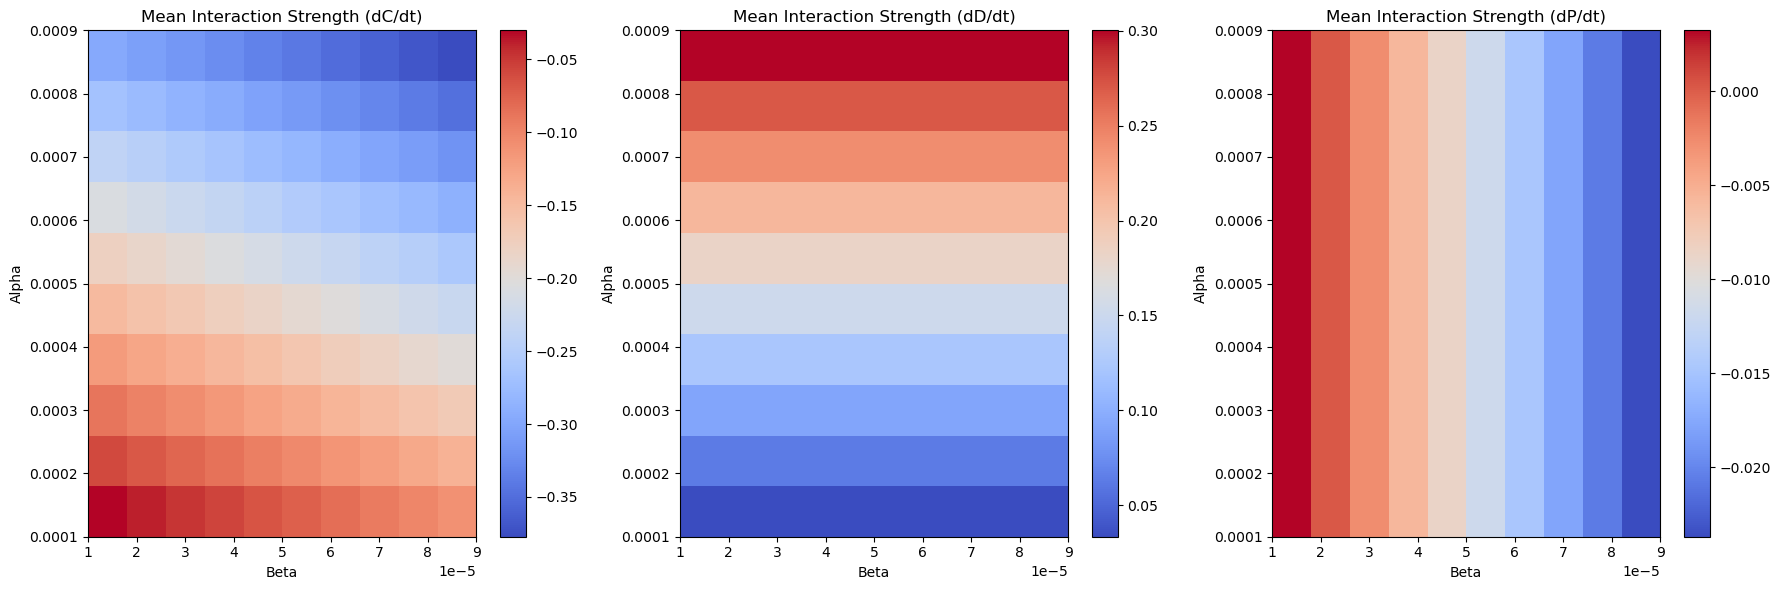

In [6]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Numerical differentiation function (finite differences)
def compute_interaction_strengths(C0, D0, P0, nu, beta, alpha, mu, gamma, eta, eps=1e-6):
    y0 = np.array([C0, D0, P0])
    t = 0  # We evaluate at an initial time
    base_rates = np.array(deriv(y0, t, nu, beta, alpha, mu, gamma, eta))
    
    interaction_matrix = np.zeros((3, 3))  # 3 populations (C, D, P) by 3 growth rates (dC, dD, dP)
    
    for i in range(3):
        perturbed_y = y0.copy()
        perturbed_y[i] += eps
        perturbed_rates = np.array(deriv(perturbed_y, t, nu, beta, alpha, mu, gamma, eta))
        interaction_matrix[:, i] = (perturbed_rates - base_rates) / eps  # Numerical derivative
        
    return interaction_matrix

# Parameters
gamma = 0.00001
mu = 0.04
eta = 0.02
nu = 0.00001

# Initial conditions
C0, D0, P0 = 1000.0, 1.0, 10.0

# Alpha and Beta ranges
alpha_values = np.linspace(0.0001, 0.0009, 10)  # Alpha range
beta_values = np.linspace(0.00001, 0.00009, 10)  # Beta range

# Preallocate arrays to store interaction strengths
mean_interaction_strengths_C = np.zeros((len(alpha_values), len(beta_values)))  # For dC/dt
mean_interaction_strengths_D = np.zeros((len(alpha_values), len(beta_values)))  # For dD/dt
mean_interaction_strengths_P = np.zeros((len(alpha_values), len(beta_values)))  # For dP/dt

# Loop over alpha and beta values
for i, alpha in enumerate(alpha_values):
    for j, beta in enumerate(beta_values):
        interaction_matrix = compute_interaction_strengths(C0, D0, P0, nu, beta, alpha, mu, gamma, eta)
        mean_interaction_strengths_C[i, j] = np.mean(interaction_matrix[0, :])  # Mean interaction affecting dC/dt
        mean_interaction_strengths_D[i, j] = np.mean(interaction_matrix[1, :])  # Mean interaction affecting dD/dt
        mean_interaction_strengths_P[i, j] = np.mean(interaction_matrix[2, :])  # Mean interaction affecting dP/dt

# Plotting heatmaps
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Heatmap for dC/dt
cax1 = axs[0].imshow(mean_interaction_strengths_C, cmap='coolwarm', aspect='auto', origin='lower',
                     extent=[beta_values[0], beta_values[-1], alpha_values[0], alpha_values[-1]])
axs[0].set_title('Mean Interaction Strength (dC/dt)')
axs[0].set_xlabel('Beta')
axs[0].set_ylabel('Alpha')
fig.colorbar(cax1, ax=axs[0])

# Heatmap for dD/dt
cax2 = axs[1].imshow(mean_interaction_strengths_D, cmap='coolwarm', aspect='auto', origin='lower',
                     extent=[beta_values[0], beta_values[-1], alpha_values[0], alpha_values[-1]])
axs[1].set_title('Mean Interaction Strength (dD/dt)')
axs[1].set_xlabel('Beta')
axs[1].set_ylabel('Alpha')
fig.colorbar(cax2, ax=axs[1])

# Heatmap for dP/dt
cax3 = axs[2].imshow(mean_interaction_strengths_P, cmap='coolwarm', aspect='auto', origin='lower',
                     extent=[beta_values[0], beta_values[-1], alpha_values[0], alpha_values[-1]])
axs[2].set_title('Mean Interaction Strength (dP/dt)')
axs[2].set_xlabel('Beta')
axs[2].set_ylabel('Alpha')
fig.colorbar(cax3, ax=axs[2])

plt.tight_layout()
plt.show()


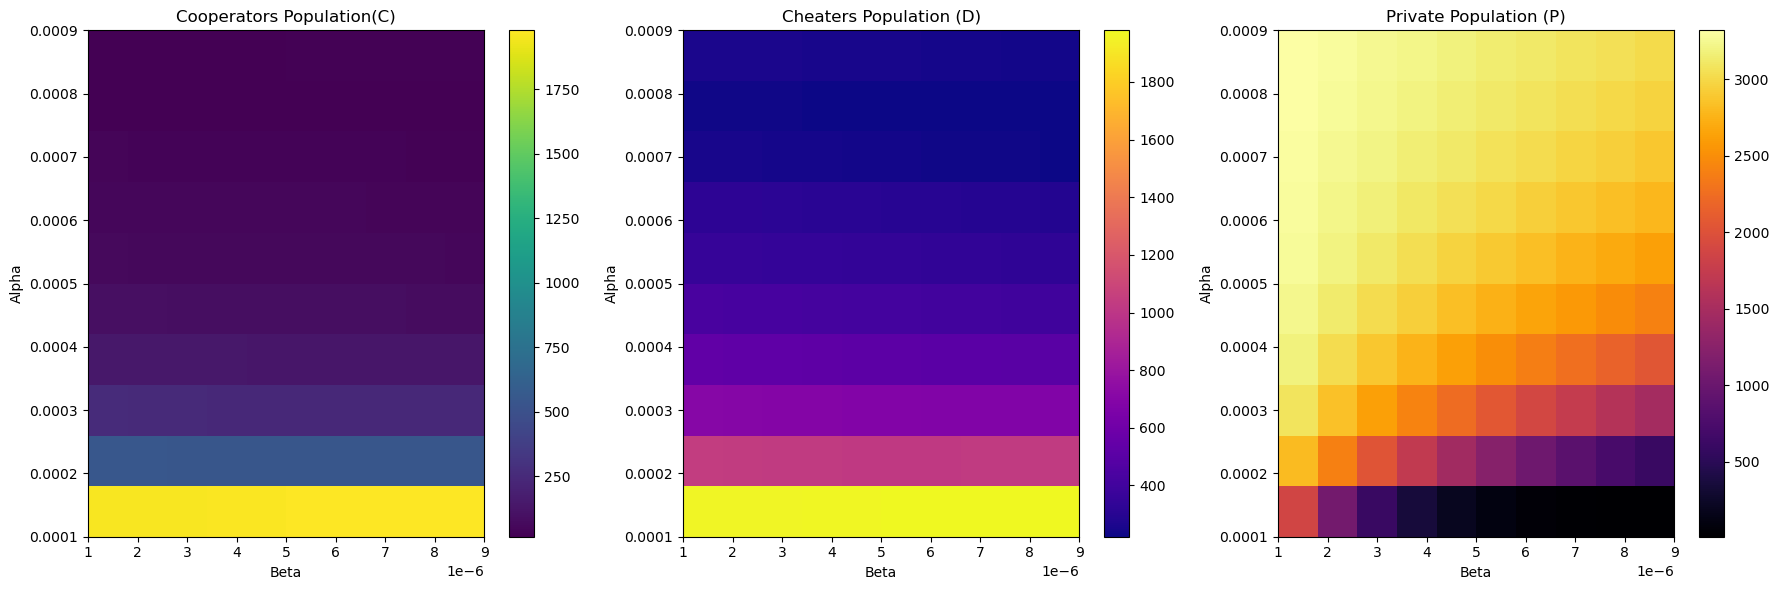

In [19]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - gamma * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
gamma = 0.000001  # cost spent by private population
mu = 0.2       # growth rate of cooperator
eta = 0.02      # growth rate of private
nu = 0.0001    # transportation cost of defector

# Initial conditions
C0, D0, P0 = 1000.0, 1.0, 10.0  # initial populations
y0 = [C0, D0, P0]

# Time grid
t = np.linspace(0, 300, 1000)

# Alpha and Beta ranges
alpha_values = np.linspace(0.0001, 0.0009, 10)  # range of alpha values
beta_values = np.linspace(0.000001, 0.000009, 10)  # range of beta values

# Preallocate arrays to store steady-state populations
final_C = np.zeros((len(alpha_values), len(beta_values)))
final_D = np.zeros((len(alpha_values), len(beta_values)))
final_P = np.zeros((len(alpha_values), len(beta_values)))

# Loop over alpha and beta values
for i, alpha in enumerate(alpha_values):
    for j, beta in enumerate(beta_values):
        # Solve the ODE system for each pair of alpha and beta
        sol = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
        C, D, P = sol.T
        
        # Store the final (steady-state) population values
        final_C[i, j] = C[-1]  # Final value of C
        final_D[i, j] = D[-1]  # Final value of D
        final_P[i, j] = P[-1]  # Final value of P

# Plotting heatmaps
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Heatmap for cooperators (C)
cax1 = axs[0].imshow(final_C, cmap='viridis', aspect='auto', origin='lower',
                     extent=[beta_values[0], beta_values[-1], alpha_values[0], alpha_values[-1]])
axs[0].set_title('Cooperators Population(C)')
axs[0].set_xlabel('Beta')
axs[0].set_ylabel('Alpha')
fig.colorbar(cax1, ax=axs[0])

# Heatmap for cheaters (D)
cax2 = axs[1].imshow(final_D, cmap='plasma', aspect='auto', origin='lower',
                     extent=[beta_values[0], beta_values[-1], alpha_values[0], alpha_values[-1]])
axs[1].set_title('Cheaters Population (D)')
axs[1].set_xlabel('Beta')
axs[1].set_ylabel('Alpha')
fig.colorbar(cax2, ax=axs[1])

# Heatmap for private population (P)
cax3 = axs[2].imshow(final_P, cmap='inferno', aspect='auto', origin='lower',
                     extent=[beta_values[0], beta_values[-1], alpha_values[0], alpha_values[-1]])
axs[2].set_title('Private Population (P)')
axs[2].set_xlabel('Beta')
axs[2].set_ylabel('Alpha')
fig.colorbar(cax3, ax=axs[2])

plt.tight_layout()
plt.show()


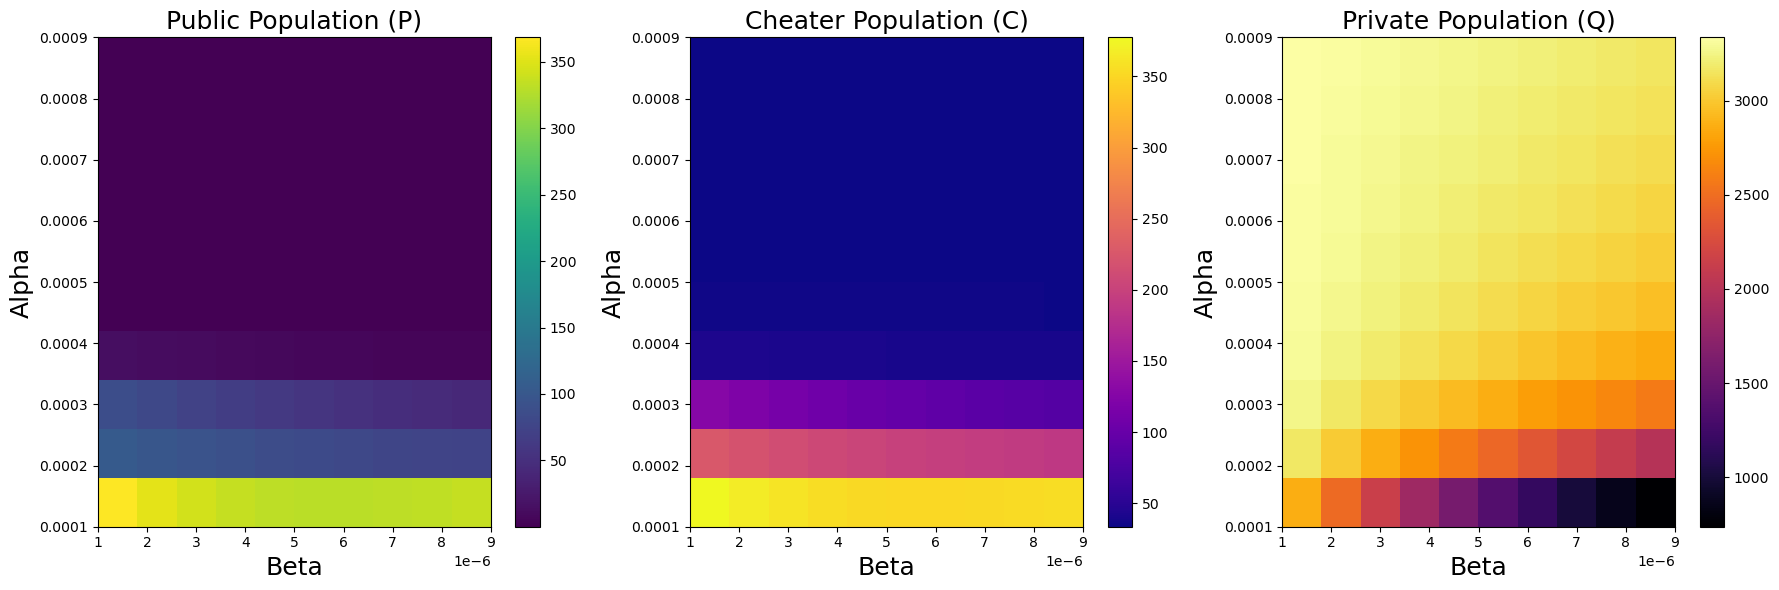

In [29]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - gamma * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
gamma = 0.000001  # cost spent by private population
mu = 0.04       # growth rate of cooperator
eta = 0.02      # growth rate of private
nu = 0.0001    # transportation cost of defector

# Initial conditions
C0, D0, P0 = 1000.0, 1.0, 10.0  # initial populations
y0 = [C0, D0, P0]

# Time grid
t = np.linspace(0, 300, 1000)

# Alpha and Beta ranges
alpha_values = np.linspace(0.0001, 0.0009, 10)  # range of alpha values
beta_values = np.linspace(0.000001, 0.000009, 10)  # range of beta values

# Preallocate arrays to store steady-state populations
final_C = np.zeros((len(alpha_values), len(beta_values)))
final_D = np.zeros((len(alpha_values), len(beta_values)))
final_P = np.zeros((len(alpha_values), len(beta_values)))

# Loop over alpha and beta values
for i, alpha in enumerate(alpha_values):
    for j, beta in enumerate(beta_values):
        # Solve the ODE system for each pair of alpha and beta
        sol = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
        C, D, P = sol.T
        
        # Store the final (steady-state) population values
        final_C[i, j] = C[-1]  # Final value of C
        final_D[i, j] = D[-1]  # Final value of D
        final_P[i, j] = P[-1]  # Final value of P

# Plotting heatmaps
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Increase font size
fontsize = 18

# Heatmap for cooperators (C)
cax1 = axs[0].imshow(final_C, cmap='viridis', aspect='auto', origin='lower',
                     extent=[beta_values[0], beta_values[-1], alpha_values[0], alpha_values[-1]])
axs[0].set_title('Public Population (P)', fontsize=fontsize)
axs[0].set_xlabel('Beta', fontsize=fontsize)
axs[0].set_ylabel('Alpha', fontsize=fontsize)
fig.colorbar(cax1, ax=axs[0])

# Heatmap for cheaters (D)
cax2 = axs[1].imshow(final_D, cmap='plasma', aspect='auto', origin='lower',
                     extent=[beta_values[0], beta_values[-1], alpha_values[0], alpha_values[-1]])
axs[1].set_title('Cheater Population (C)', fontsize=fontsize)
axs[1].set_xlabel('Beta', fontsize=fontsize)
axs[1].set_ylabel('Alpha', fontsize=fontsize)
fig.colorbar(cax2, ax=axs[1])

# Heatmap for private population (P)
cax3 = axs[2].imshow(final_P, cmap='inferno', aspect='auto', origin='lower',
                     extent=[beta_values[0], beta_values[-1], alpha_values[0], alpha_values[-1]])
axs[2].set_title('Private Population (Q)', fontsize=fontsize)
axs[2].set_xlabel('Beta', fontsize=fontsize)
axs[2].set_ylabel('Alpha', fontsize=fontsize)
fig.colorbar(cax3, ax=axs[2])

plt.tight_layout()
plt.show()


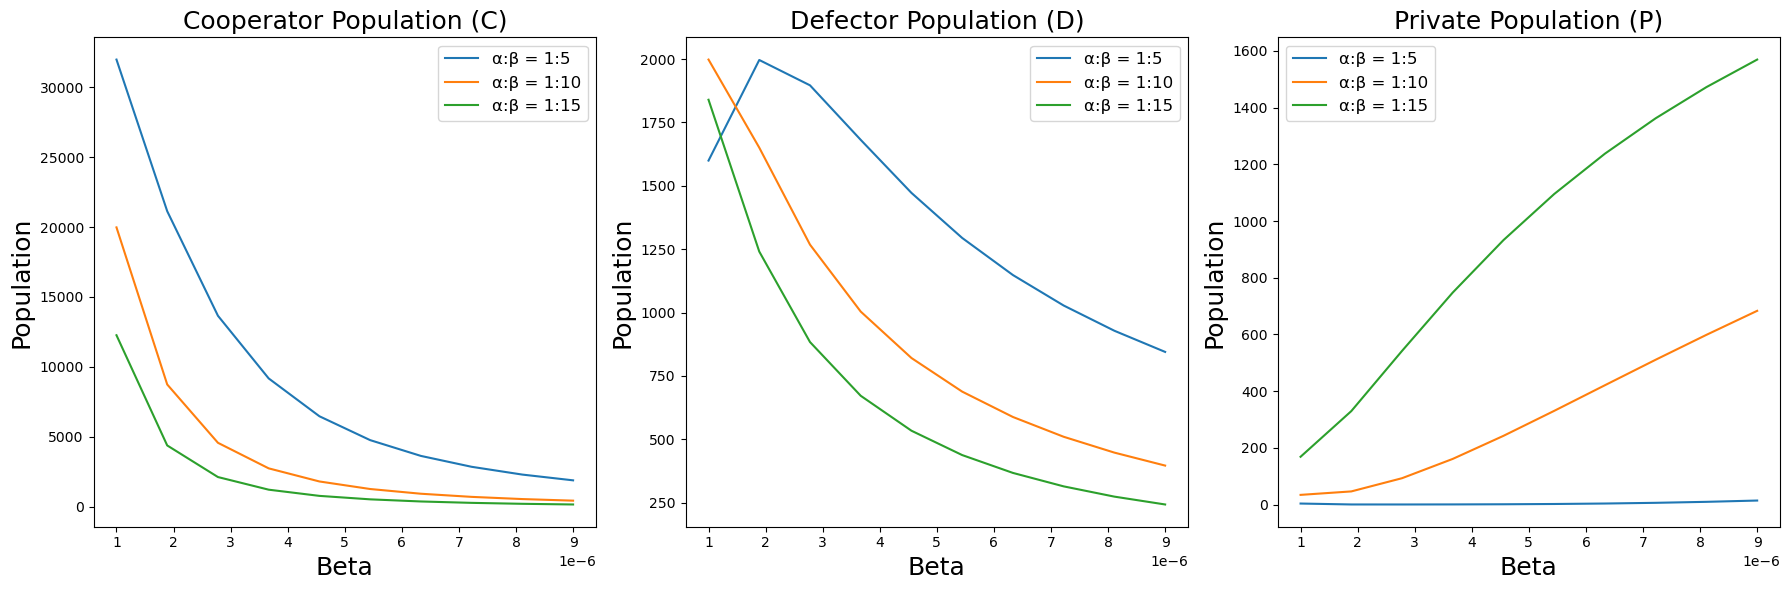

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - gamma * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Parameters
gamma = 0.000001  # cost spent by private population
mu = 0.04       # growth rate of cooperator
eta = 0.02      # growth rate of private
nu = 0.0001    # transportation cost of defector

# Initial conditions
C0, D0, P0 = 1000.0, 10.0, 10.0  # initial populations
y0 = [C0, D0, P0]

# Time grid
t = np.linspace(0, 300, 1000)

# Alpha-to-beta ratios
ratios = [5, 10, 15]  # Example ratios of alpha to beta
beta_values = np.linspace(0.000001, 0.000009, 10)  # Independent parameter

# Preallocate arrays to store steady-state populations
results = {ratio: {"C": [], "D": [], "P": []} for ratio in ratios}

# Loop over ratios
for ratio in ratios:
    for beta in beta_values:
        alpha = ratio * beta  # Calculate alpha based on the fixed ratio
        # Solve the ODE system
        sol = odeint(deriv, y0, t, args=(nu, beta, alpha, mu, gamma, eta))
        C, D, P = sol.T
        
        # Store the final (steady-state) populations
        results[ratio]["C"].append(C[-1])
        results[ratio]["D"].append(D[-1])
        results[ratio]["P"].append(P[-1])

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

fontsize = 18
for i, (pop, title, color) in enumerate(zip(
    ["C", "D", "P"], 
    ["Cooperator Population (C)", "Defector Population (D)", "Private Population (P)"],
    ["viridis", "plasma", "inferno"]
)):
    for ratio in ratios:
        axs[i].plot(beta_values, results[ratio][pop], label=f"α:β = 1:{ratio}")
    axs[i].set_title(title, fontsize=fontsize)
    axs[i].set_xlabel('Beta', fontsize=fontsize)
    axs[i].set_ylabel('Population', fontsize=fontsize)
    axs[i].legend(fontsize=12)

plt.tight_layout()
plt.show()


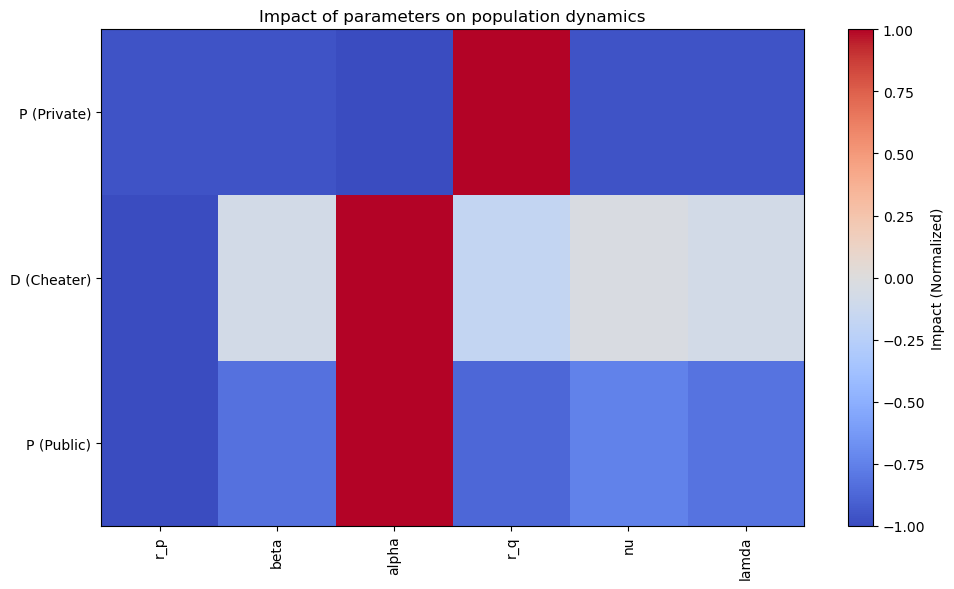

In [65]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, r_p, lamda, r_q):
    C, D, P = y
    dCdt =  r_p * C - alpha * C * D - beta * C * P - lamda * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = r_q * P - beta * C * P - lamda * P * P  # private population
    return dCdt, dDdt, dPdt

# Initial conditions and time grid
C0, D0, P0 = 100.0, 1.0, 1.0  # initial populations
y0 = [C0, D0, P0]
t = np.linspace(0, 300, 1000)

# Default parameter values for reference
default_params = {
    'alpha': 0.0001,
    'beta': 0.000001,
    'r_p': 0.04,
    'r_q': 0.02,
    'nu': 0.0001,
    'lamda': 0.00001
}

# Function to run the model and return the steady-state populations
def run_simulation(params):
    sol = odeint(deriv, y0, t, args=(params['nu'], params['beta'], params['alpha'], params['r_p'], params['lamda'], params['r_q']))
    C, D, P = sol.T
    return C[-1], D[-1], P[-1]  # return the steady-state values of C, D, and P

# List of parameters to evaluate the impact on populations
params_to_evaluate = ['r_p', 'beta', 'alpha', 'r_q', 'nu', 'lamda']

# Store the impacts (positive or negative) on C, D, and P
impact_results = {'C': [], 'D': [], 'P': []}

# Loop over each parameter and evaluate its impact on each population
perturbation_factor = 0.3  # ±30% change in parameter value
for param in params_to_evaluate:
    impacts_C = []
    impacts_D = []
    impacts_P = []
    
    # Evaluate the effect of a ±30% perturbation
    for val in [default_params[param] * (1 - perturbation_factor), 
                default_params[param] * (1 + perturbation_factor)]:
        # Update the selected parameter and run the simulation
        params = {**default_params, param: val}
        C, D, P = run_simulation(params)
        
        # Get the default steady-state populations
        default_C, default_D, default_P = run_simulation(default_params)
        
        # Calculate the relative change (positive or negative impact)
        impact_on_C = np.sign(C - default_C) * np.abs(C - default_C) / default_C
        impact_on_D = np.sign(D - default_D) * np.abs(D - default_D) / default_D
        impact_on_P = np.sign(P - default_P) * np.abs(P - default_P) / default_P

        # Store the impacts
        impacts_C.append(impact_on_C)
        impacts_D.append(impact_on_D)
        impacts_P.append(impact_on_P)
    
    # Add the average of the impacts for the current parameter
    impact_results['C'].append(np.mean(impacts_C))
    impact_results['D'].append(np.mean(impacts_D))
    impact_results['P'].append(np.mean(impacts_P))

# Convert the impact results to a numpy array for heatmap plotting
impact_results_C = np.array(impact_results['C'])
impact_results_D = np.array(impact_results['D'])
impact_results_P = np.array(impact_results['P'])

# Function to normalize the impact values between -1 and 1
def normalize_impact(impact_array):
    min_val = np.min(impact_array)
    max_val = np.max(impact_array)
    
    # Normalize the impact values between -1 and 1
    return 2 * (impact_array - min_val) / (max_val - min_val) - 1

# Normalize the impact results
impact_results_C_normalized = normalize_impact(impact_results_C)
impact_results_D_normalized = normalize_impact(impact_results_D)
impact_results_P_normalized = normalize_impact(impact_results_P)

# Combine the results into one matrix for the heatmap
heatmap_data = np.vstack([impact_results_C_normalized, impact_results_D_normalized, impact_results_P_normalized])

# Plot the heatmap
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the heatmap
cax = ax.imshow(heatmap_data, cmap='coolwarm', aspect='auto', origin='lower', vmin=-1, vmax=1)

# Set x-axis and y-axis labels
ax.set_xticks(np.arange(len(params_to_evaluate)))
ax.set_xticklabels(params_to_evaluate, rotation=90)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['P (Public)', 'D (Cheater)', 'P (Private)'])

# Add color bar
fig.colorbar(cax, ax=ax, label='Impact (Normalized)')

plt.title("Impact of parameters on population dynamics")
plt.tight_layout()
plt.show()


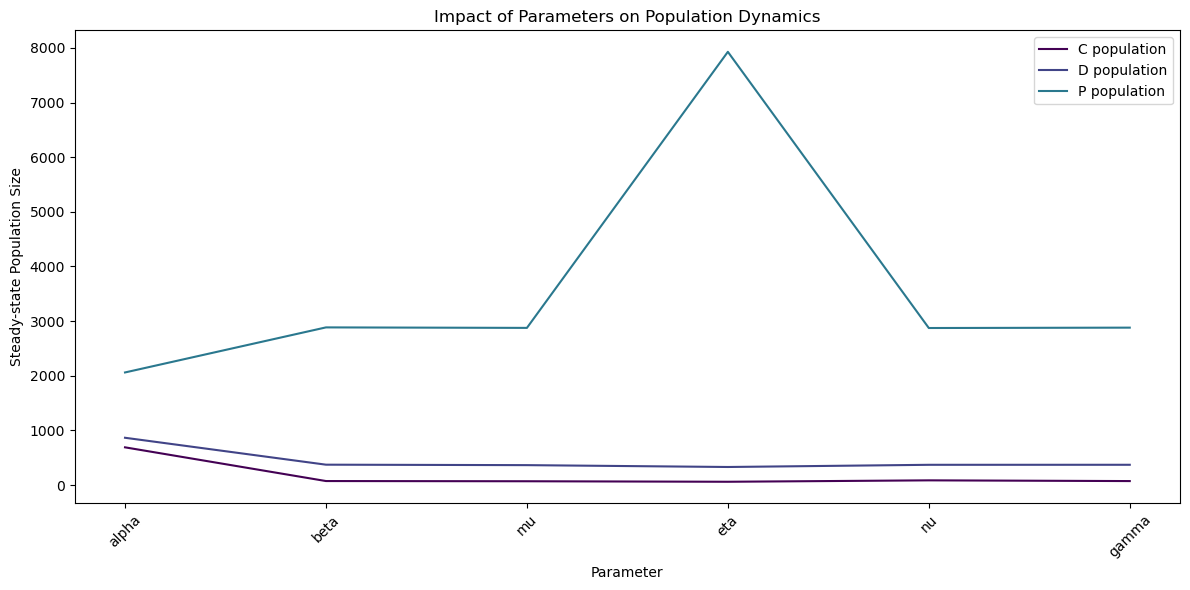

In [14]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the system of ODEs
def deriv(y, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = y
    dCdt = mu * C - alpha * C * D - beta * C * P - gamma * C * C  # cooperator population
    dDdt = -nu * D * D + alpha * C * D  # defector population
    dPdt = eta * P - beta * C * P - gamma * P * P  # private population
    return dCdt, dDdt, dPdt

# Initial conditions and time grid
C0, D0, P0 = 1000.0, 1.0, 10.0  # initial populations
y0 = [C0, D0, P0]
t = np.linspace(0, 300, 1000)

# Default parameter values for reference
default_params = {
    'alpha': 0.0005,
    'beta': 0.000005,
    'mu': 0.2,
    'eta': 0.02,
    'nu': 0.0001,
    'gamma': 0.000001
}

# Function to run the model and return the steady-state populations
def run_simulation(params):
    sol = odeint(deriv, y0, t, args=(params['nu'], params['beta'], params['alpha'], params['mu'], params['gamma'], params['eta']))
    C, D, P = sol.T
    return C[-1], D[-1], P[-1]  # return the steady-state values of C, D, and P

# List of parameters to vary and their ranges
param_ranges = {
    'alpha': [0.0001, 0.0005, 0.0009],
    'beta': [0.000001, 0.000005, 0.000009],
    'mu': [0.1, 0.2, 0.3],
    'eta': [0.01, 0.02, 0.03],
    'nu': [0.00005, 0.0001, 0.00015],
    'gamma': [0.0000005, 0.000001, 0.0000015]
}

# Prepare a dictionary to store the results of steady-state populations
impact_results = {
    'C': [],
    'D': [],
    'P': []
}

# Loop over each parameter and calculate the steady-state populations
for param, values in param_ranges.items():
    steady_C = []
    steady_D = []
    steady_P = []
    
    for val in values:
        # Update the parameters and run the simulation
        params = {**default_params, param: val}
        C, D, P = run_simulation(params)
        
        # Append the steady-state populations
        steady_C.append(C)
        steady_D.append(D)
        steady_P.append(P)
    
    # Store the results
    impact_results['C'].append(steady_C)
    impact_results['D'].append(steady_D)
    impact_results['P'].append(steady_P)

# Plotting the impact of each parameter on population dynamics
fig, ax = plt.subplots(figsize=(12, 6))

# Number of parameters to plot
num_params = len(param_ranges)

# Colors for each parameter for distinction
colors = plt.cm.viridis(np.linspace(0, 1, num_params))

# Loop through each population type and plot the effect of parameter variations
for i, (pop_type, results) in enumerate(impact_results.items()):
    ax.plot(range(num_params), [np.mean(r) for r in results], label=f'{pop_type} population', color=colors[i])

# Customize the plot
ax.set_xticks(range(num_params))
ax.set_xticklabels(list(param_ranges.keys()), rotation=45)
ax.set_xlabel('Parameter')
ax.set_ylabel('Steady-state Population Size')
ax.set_title('Impact of Parameters on Population Dynamics')
ax.legend()

plt.tight_layout()
plt.show()


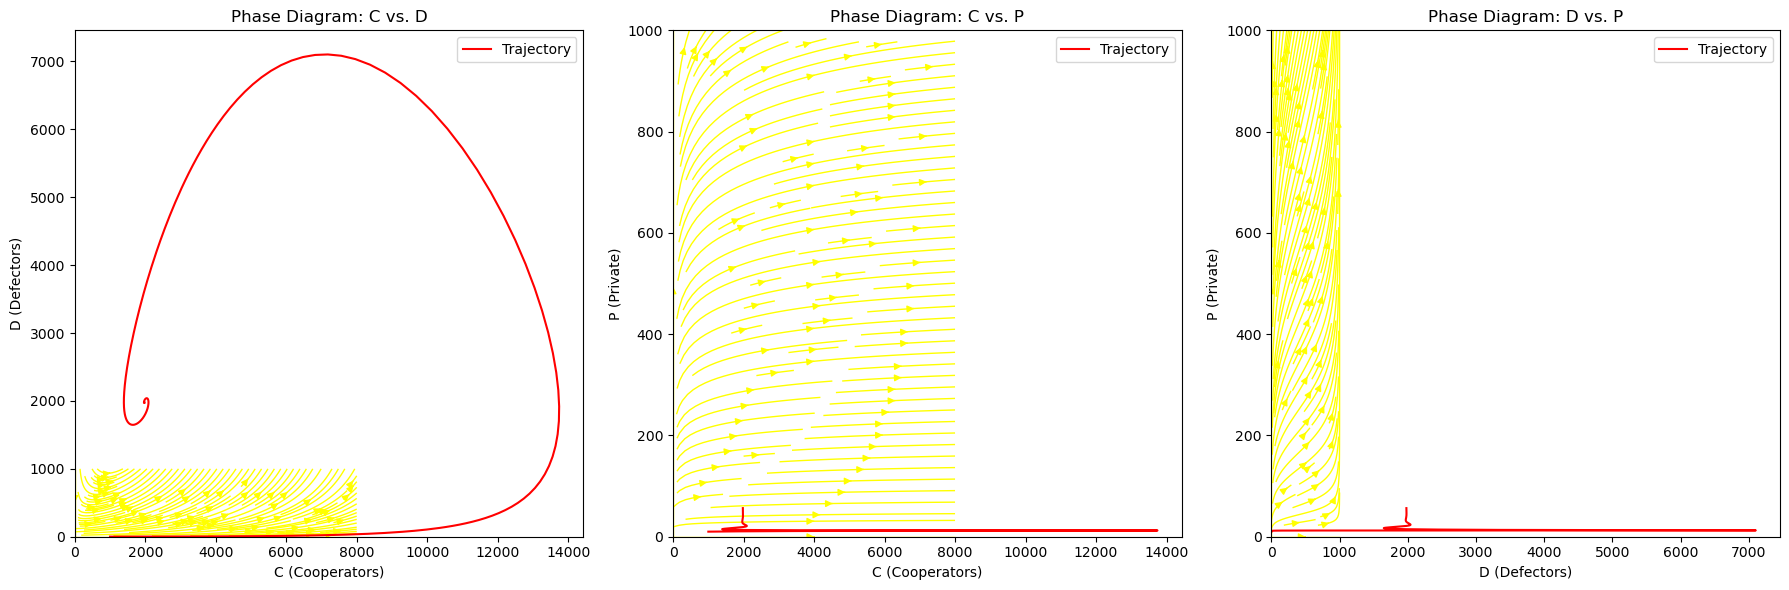

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ODE function for populations C, D, and P based on the defined model
def population_dynamics(N, t, nu, beta, alpha, mu, gamma, eta):
    C, D, P = N
    dCdt = mu * C - alpha * C * D - beta * C * P - beta * C**2  # Cooperator population
    dDdt = alpha * C * D - nu * D**2  # Defector population
    dPdt = eta * P - beta * C * P - gamma * P**2  # Private population
    return np.array([dCdt, dDdt, dPdt])

# Parameters from the new system
mu = 0.2       # Growth rate of cooperator
alpha = 0.0001   # Interaction rate between cooperators and defectors
beta = 0.000001    # Interaction rate between cooperators and private, and intra-competition
nu = 0.0001    # Transportation cost of defectors
eta = 0.02     # Growth rate of private population
gamma = 0.000001  # Cost spent by private population

# Initial conditions for cooperators, defectors, and private populations
C0, D0, P0 = 1000.0, 1.0, 10.0

# Time vector
t = np.linspace(0, 100, 1000)

# Solve the system of ODEs
sol = odeint(population_dynamics, [C0, D0, P0], t, args=(nu, beta, alpha, mu, gamma, eta))

# Setup for phase diagrams
C_range = np.linspace(0, 8000, 14000)
D_range = np.linspace(0, 1000, 14000)
P_range = np.linspace(0, 1000, 14000)

# Adjusting the scaling and density of the streamplots for better visualization

# Recalculate vector fields for each pair of variables (C-D, C-P, D-P) with refined scaling
C_grid, D_grid = np.meshgrid(C_range, D_range)
dCdt_CD, dDdt_CD, _ = population_dynamics([C_grid, D_grid, np.ones_like(C_grid) * P0], 0, nu, beta, alpha, mu, gamma, eta)
C_grid, P_grid = np.meshgrid(C_range, P_range)
dCdt_CP, _, dPdt_CP = population_dynamics([C_grid, np.ones_like(C_grid) * D0, P_grid], 0, nu, beta, alpha, mu, gamma, eta)
D_grid, P_grid = np.meshgrid(D_range, P_range)
_, dDdt_DP, dPdt_DP = population_dynamics([np.ones_like(D_grid) * C0, D_grid, P_grid], 0, nu, beta, alpha, mu, gamma, eta)

# Normalize the vector fields for better streamline visualization
def normalize_vector_field(X, Y):
    magnitude = np.sqrt(X**2 + Y**2)
    X_normalized = np.divide(X, magnitude, where=magnitude!=0)
    Y_normalized = np.divide(Y, magnitude, where=magnitude!=0)
    return X_normalized, Y_normalized

dCdt_CD, dDdt_CD = normalize_vector_field(dCdt_CD, dDdt_CD)
dCdt_CP, dPdt_CP = normalize_vector_field(dCdt_CP, dPdt_CP)
dDdt_DP, dPdt_DP = normalize_vector_field(dDdt_DP, dPdt_DP)

# Plot the updated phase diagrams with normalized streamplots
plt.figure(figsize=(18, 6))

# C vs. D with normalized streamplot
plt.subplot(1, 3, 1)
plt.streamplot(C_range, D_range, dCdt_CD, dDdt_CD, density=1.5, color='yellow', linewidth=1)
plt.plot(sol[:, 0], sol[:, 1], 'r-', label='Trajectory')
plt.xlabel('C (Cooperators)')
plt.ylabel('D (Defectors)')
plt.title('Phase Diagram: C vs. D')
plt.legend()

# C vs. P with normalized streamplot
plt.subplot(1, 3, 2)
plt.streamplot(C_range, P_range, dCdt_CP, dPdt_CP, density=1.5, color='yellow', linewidth=1)
plt.plot(sol[:, 0], sol[:, 2], 'r-', label='Trajectory')
plt.xlabel('C (Cooperators)')
plt.ylabel('P (Private)')
plt.title('Phase Diagram: C vs. P')
plt.legend()

# D vs. P with normalized streamplot
plt.subplot(1, 3, 3)
plt.streamplot(D_range, P_range, dDdt_DP, dPdt_DP, density=1.5, color='yellow', linewidth=1)
plt.plot(sol[:, 1], sol[:, 2], 'r-', label='Trajectory')
plt.xlabel('D (Defectors)')
plt.ylabel('P (Private)')
plt.title('Phase Diagram: D vs. P')
plt.legend()

plt.tight_layout()
plt.show()


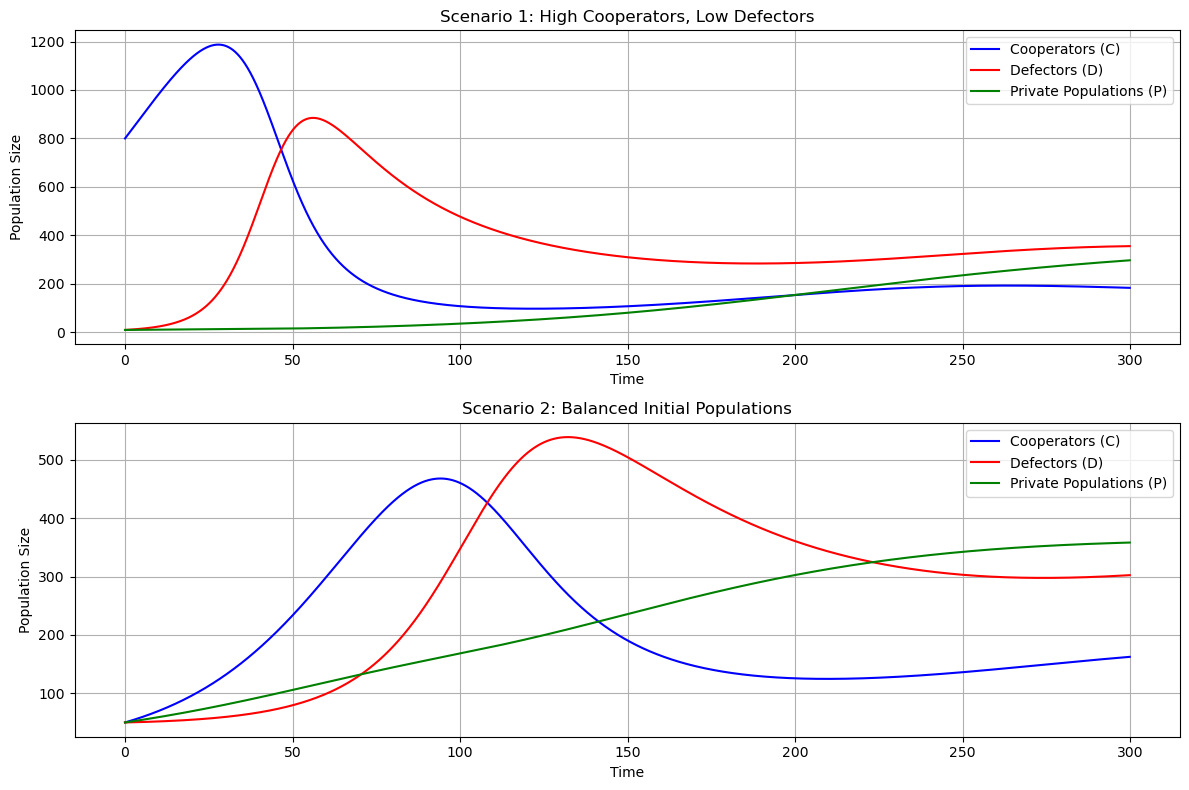

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
r_c = 0.04  # intrinsic growth rate of cooperators
r_P = 0.02  # intrinsic growth rate of private populations
alpha = 0.0001  # benefit shared with defectors
beta = 0.00001  # competition parameter between public and private populations
lambda_c = 0.00002  # carrying capacity term for cooperators
nu = 0.00005  # carrying capacity term for defectors
gamma = 0.00005  # carrying capacity term for private populations
K_C = 100000  # carrying capacity for cooperators
K_D = 100000  # carrying capacity for defectors
K_P = 100000  # carrying capacity for private populations

# Time settings
t_max = 300
dt = 0.1
time_steps = int(t_max / dt)

# Initialize arrays for populations
C1 = np.zeros(time_steps)  # Cooperators for scenario 1
D1 = np.zeros(time_steps)  # Defectors for scenario 1
P1 = np.zeros(time_steps)  # Private populations for scenario 1

C2 = np.zeros(time_steps)  # Cooperators for scenario 2
D2 = np.zeros(time_steps)  # Defectors for scenario 2
P2 = np.zeros(time_steps)  # Private populations for scenario 2

# Initial conditions
C1[0], D1[0], P1[0] = 800, 10, 10  # Scenario 1
C2[0], D2[0], P2[0] = 50, 50, 50  # Scenario 2

# Simulation loop
for t in range(1, time_steps):
    # Scenario 1
    C1[t] = C1[t-1] + dt * (r_c * C1[t-1] / np.sqrt(1 - (C1[t-1]**2 / K_C**2)) 
                            - alpha * C1[t-1] * D1[t-1] 
                            - beta * C1[t-1] * P1[t-1] 
                            - lambda_c * C1[t-1]**2)

    D1[t] = D1[t-1] + dt * (alpha * C1[t-1] * D1[t-1] / np.sqrt(1 - (D1[t-1]**2 / K_D**2)) 
                            - nu * D1[t-1]**2)

    P1[t] = P1[t-1] + dt * (r_P * P1[t-1] / np.sqrt(1 - (P1[t-1]**2 / K_P**2)) 
                            - beta * P1[t-1] * C1[t-1] 
                            - gamma * P1[t-1]**2)

    # Scenario 2
    C2[t] = C2[t-1] + dt * (r_c * C2[t-1] / np.sqrt(1 - (C2[t-1]**2 / K_C**2)) 
                            - alpha * C2[t-1] * D2[t-1] 
                            - beta * C2[t-1] * P2[t-1] 
                            - lambda_c * C2[t-1]**2)

    D2[t] = D2[t-1] + dt * (alpha * C2[t-1] * D2[t-1] / np.sqrt(1 - (D2[t-1]**2 / K_D**2)) 
                            - nu * D2[t-1]**2)

    P2[t] = P2[t-1] + dt * (r_P * P2[t-1] / np.sqrt(1 - (P2[t-1]**2 / K_P**2)) 
                            - beta * P2[t-1] * C2[t-1] 
                            - gamma * P2[t-1]**2)

# Plotting results
plt.figure(figsize=(12, 8))

# Scenario 1
plt.subplot(2, 1, 1)
plt.title('Scenario 1: High Cooperators, Low Defectors')
plt.plot(np.arange(0, t_max, dt), C1, label='Cooperators (C)', color='blue')
plt.plot(np.arange(0, t_max, dt), D1, label='Defectors (D)', color='red')
plt.plot(np.arange(0, t_max, dt), P1, label='Private Populations (P)', color='green')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.legend()
plt.grid()

# Scenario 2
plt.subplot(2, 1, 2)
plt.title('Scenario 2: Balanced Initial Populations')
plt.plot(np.arange(0, t_max, dt), C2, label='Cooperators (C)', color='blue')
plt.plot(np.arange(0, t_max, dt), D2, label='Defectors (D)', color='red')
plt.plot(np.arange(0, t_max, dt), P2, label='Private Populations (P)', color='green')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


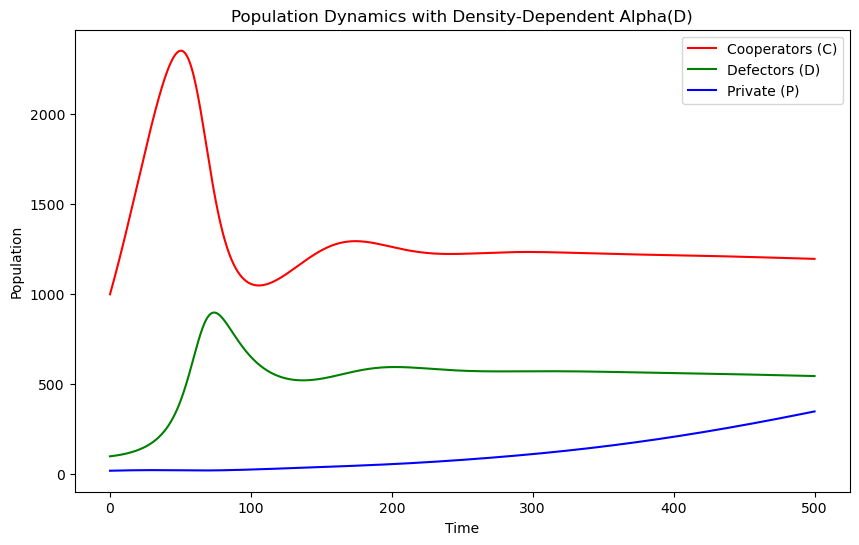

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ODE function with density-dependent alpha(D)
def population_dynamics(N, t, alpha_0, k_alpha, K, beta, nu, lambda_, gamma, mu, eta):
    C, D, P = N
    
    # Density-dependent alpha(D)
    alpha = alpha_0 + k_alpha * D / (D + K)  # alpha increases with defector density
    
    # Differential equations
    dCdt = mu * C - alpha * C * D - beta * C * P - lambda_ * C**2  # Cooperator population
    dDdt = alpha * C * D - nu * D**2  # Defector population
    dPdt = eta * P - beta * C * P - gamma * P**2  # Private population
    return np.array([dCdt, dDdt, dPdt])

# Parameters
mu = 0.04      # Cooperator growth rate
eta = 0.02    # Private population growth rate
lambda_ = 0.00001  # Intra-competition among cooperators
nu = 0.0001   # Defector transportation cost
beta = 0.00001  # Interaction between C and P
gamma = 0.00001  # Cost for private population

# Parameters for density-dependent alpha(D)
alpha_0 = 0.00001  # Base alpha (interaction between C and D)
k_alpha = 0.0001  # Impact of defectors on alpha
K = 1000  # Controls saturation of alpha with increasing D

# Initial conditions
C0, D0, P0 = 1000.0, 100.0, 20.0  # Starting populations
initial_conditions = [C0, D0, P0]

# Time vector
t = np.linspace(0, 500, 1000)

# Integrate the system using odeint
sol = odeint(population_dynamics, initial_conditions, t, args=(alpha_0, k_alpha, K, beta, nu, lambda_, gamma, mu, eta))

# Plot the time series of the population
plt.figure(figsize=(10, 6))
plt.plot(t, sol[:, 0], 'r-', label='Cooperators (C)')
plt.plot(t, sol[:, 1], 'g-', label='Defectors (D)')
plt.plot(t, sol[:, 2], 'b-', label='Private (P)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Population Dynamics with Density-Dependent Alpha(D)')
plt.legend()
plt.show()


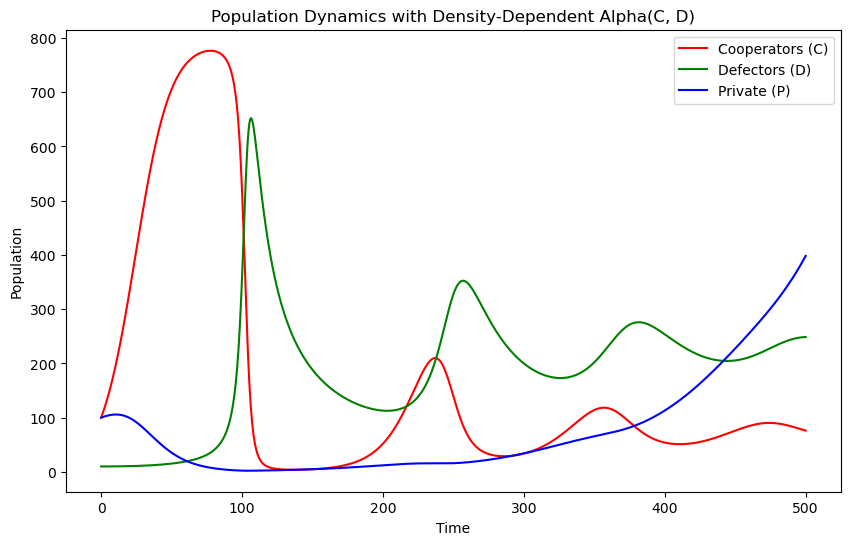

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the updated model with the new alpha(C, D)
def population_dynamics(N, t, mu, delta, K_alpha, nu, lambda_, eta, gamma):
    C, D, P = N
    
    # Density-dependent alpha(C, D)
    alpha = (delta * D) / (K_alpha + D)
    
    # Population dynamics equations
    dCdt = mu * C - alpha * C * D - lambda_ * C**2  # Cooperator population
    dDdt = alpha * C * D - nu * D**2  # Defector population
    dPdt = eta * P - lambda_ * C * P - gamma * P**2  # Private population
    
    return np.array([dCdt, dDdt, dPdt])

# Parameters
mu = 0.08       # Growth rate of cooperators
delta = 0.001  # Maximum intensity of defector's impact on cooperators
K_alpha = 500   # Defector density at half-maximal effect on cooperators
nu = 0.0001    # Defector cost
lambda_ = 0.0001  # Cooperator self-limiting factor (C^2 term)
eta = 0.02     # Growth rate of private population
gamma = 0.000001  # Private population cost

# Initial conditions
C0, D0, P0 = 100.0, 10.0, 100.0  # Start with higher initial cheater density
initial_conditions = [C0, D0, P0]

# Time points for the simulation
time_points = np.linspace(0, 500, 1000)

# Solve the system of ODEs
solution = odeint(population_dynamics, initial_conditions, time_points, args=(mu, delta, K_alpha, nu, lambda_, eta, gamma))

# Extract the solutions
C_solution, D_solution, P_solution = solution.T

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, C_solution, 'r-', label='Cooperators (C)')
plt.plot(time_points, D_solution, 'g-', label='Defectors (D)')
plt.plot(time_points, P_solution, 'b-', label='Private (P)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Population Dynamics with Density-Dependent Alpha(C, D)')
plt.legend()
plt.show()


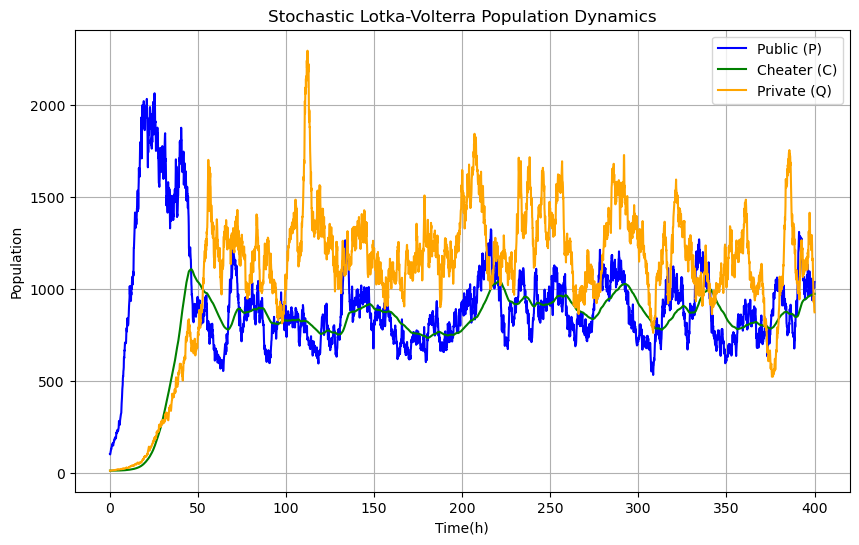

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
r_c0 = 0.2  # Mean growth rate of cooperators
r_p0 = 0.15  # Mean growth rate of private population
alpha = 0.0001  # Interaction between cooperators and defectors
beta = 0.00002  # Interaction between cooperators and private
lambda_ = 0.0001  # Self-limiting term for cooperators
nu = 0.0001  # Self-limiting term for defectors
gamma = 0.0001  # Self-limiting term for private population

sigma_c = 0.1 # Noise intensity for cooperator growth
sigma_p = 0.1  # Noise intensity for private population growth

# Simulation parameters
T = 400  # Total time
dt = 0.1  # Time step
n_steps = int(T / dt)
time = np.linspace(0, T, n_steps)

# Initial conditions
C0 = 100  # Initial population of cooperators
D0 = 10  # Initial population of defectors
P0 = 10  # Initial population of private population

# Arrays to store population values
C = np.zeros(n_steps)
D = np.zeros(n_steps)
P = np.zeros(n_steps)

# Set initial values
C[0] = C0
D[0] = D0
P[0] = P0

# Euler-Maruyama method for stochastic differential equations
for t in range(1, n_steps):
    dW_c = np.random.normal(0, np.sqrt(dt))  # Gaussian white noise for C
    dW_p = np.random.normal(0, np.sqrt(dt))  # Gaussian white noise for P
    
    dC = (r_c0 * C[t-1] - alpha * C[t-1] * D[t-1] - beta * C[t-1] * P[t-1] - lambda_ * C[t-1]**2) * dt \
         + sigma_c * C[t-1] * dW_c
    dD = (alpha * C[t-1] * D[t-1] - nu * D[t-1]**2) * dt
    dP = (r_p0 * P[t-1] - beta * P[t-1] * C[t-1] - gamma * P[t-1]**2) * dt \
         + sigma_p * P[t-1] * dW_p
    
    # Update populations
    C[t] = C[t-1] + dC
    D[t] = D[t-1] + dD
    P[t] = P[t-1] + dP
    
    # Ensure populations don't go negative
    C[t] = max(C[t], 0)
    D[t] = max(D[t], 0)
    P[t] = max(P[t], 0)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time, C, label='Public (P)', color='blue')
plt.plot(time, D, label='Cheater (C)', color='green')
plt.plot(time, P, label='Private (Q)', color='orange')
plt.title('Stochastic Lotka-Volterra Population Dynamics')
plt.xlabel('Time(h)')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()


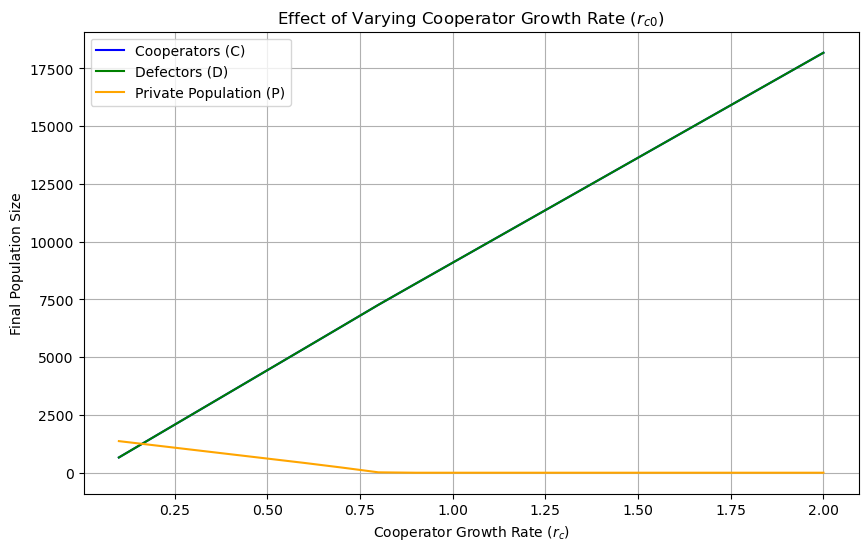

In [3]:
# Re-executing the code to simulate bifurcation analysis for varying r_c0 (cooperator growth rate)

import numpy as np
import matplotlib.pyplot as plt

# Parameters (same as before, except for r_c0 which will vary)
r_p0 = 0.15 # Mean growth rate of private population
alpha = 0.0001  # Interaction between cooperators and defectors
beta = 0.00002  # Interaction between cooperators and private
lambda_ = 0.00001  # Self-limiting term for cooperators
nu = 0.0001  # Self-limiting term for defectors
gamma = 0.0001  # Self-limiting term for private population

# Simulation parameters
T = 300  # Total time
dt = 0.1  # Time step
n_steps = int(T / dt)
time = np.linspace(0, T, n_steps)

# Initial conditions
C0 = 100  # Initial population of cooperators
D0 = 10  # Initial population of defectors
P0 = 10  # Initial population of private population

# Range of r_c0 to test
r_c0_values = np.linspace(0.1, 2.0, 20)

# Arrays to store final population values for each r_c0
final_C = np.zeros_like(r_c0_values)
final_D = np.zeros_like(r_c0_values)
final_P = np.zeros_like(r_c0_values)

# Simulate for each r_c0 value
for i, r_c0 in enumerate(r_c0_values):
    # Arrays to store population values for each run
    C = np.zeros(n_steps)
    D = np.zeros(n_steps)
    P = np.zeros(n_steps)
    
    # Set initial values
    C[0] = C0
    D[0] = D0
    P[0] = P0

    # Deterministic Lotka-Volterra without noise
    for t in range(1, n_steps):
        dC = (r_c0 * C[t-1] - alpha * C[t-1] * D[t-1] - beta * C[t-1] * P[t-1] - lambda_ * C[t-1]**2) * dt
        dD = (alpha * C[t-1] * D[t-1] - nu * D[t-1]**2) * dt
        dP = (r_p0 * P[t-1] - beta * P[t-1] * C[t-1] - gamma * P[t-1]**2) * dt

        # Update populations
        C[t] = C[t-1] + dC
        D[t] = D[t-1] + dD
        P[t] = P[t-1] + dP

        # Ensure populations don't go negative
        C[t] = max(C[t], 0)
        D[t] = max(D[t], 0)
        P[t] = max(P[t], 0)

    # Store the final population values
    final_C[i] = C[-1]
    final_D[i] = D[-1]
    final_P[i] = P[-1]

# Plotting bifurcation diagram
plt.figure(figsize=(10, 6))
plt.plot(r_c0_values, final_C, label='Cooperators (C)', color='blue')
plt.plot(r_c0_values, final_D, label='Defectors (D)', color='green')
plt.plot(r_c0_values, final_P, label='Private Population (P)', color='orange')
plt.title('Effect of Varying Cooperator Growth Rate ($r_{c0}$)')
plt.xlabel('Cooperator Growth Rate ($r_{c}$)')
plt.ylabel('Final Population Size')
plt.legend()
plt.grid(True)
plt.show()


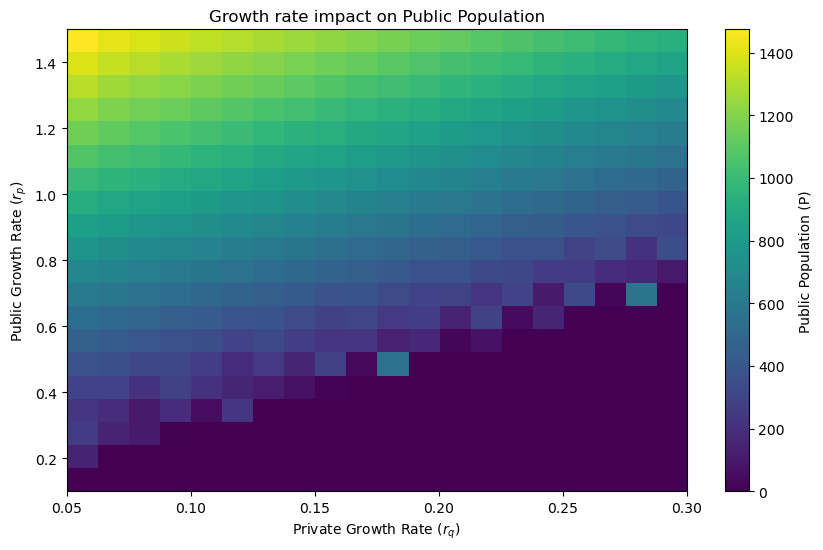

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (fixed except for r_c and r_p)
alpha = 0.0001  # Interaction between cooperators and defectors
beta = 0.00002  # Interaction between cooperators and private population
lambda_ = 0.00001  # Self-limiting term for cooperators
nu = 0.00001  # Self-limiting term for defectors
gamma = 0.00001  # Self-limiting term for private population

# Simulation parameters
T = 300  # Total simulation time
dt = 0.1  # Time step
n_steps = int(T / dt)
time = np.linspace(0, T, n_steps)

# Initial conditions
C0 = 100  # Initial population of cooperators
D0 = 10   # Initial population of defectors
P0 = 10   # Initial population of private population

# Range of r_c and r_p values to test
r_c_values = np.linspace(0.1, 1.5, 20)
r_p_values = np.linspace(0.05, 0.3, 20)

# Arrays to store final population sizes for each (r_c, r_p) combination
final_C = np.zeros((len(r_c_values), len(r_p_values)))
final_D = np.zeros((len(r_c_values), len(r_p_values)))
final_P = np.zeros((len(r_c_values), len(r_p_values)))

# Simulate for each combination of r_c and r_p
for i, r_c in enumerate(r_c_values):
    for j, r_p in enumerate(r_p_values):
        # Initialize populations for this simulation
        C = np.zeros(n_steps)
        D = np.zeros(n_steps)
        P = np.zeros(n_steps)
        C[0], D[0], P[0] = C0, D0, P0

        # Euler integration for population dynamics
        for t in range(1, n_steps):
            dC = (r_c * C[t-1] - alpha * C[t-1] * D[t-1] - beta * C[t-1] * P[t-1] - lambda_ * C[t-1]**2) * dt
            dD = (alpha * C[t-1] * D[t-1] - nu * D[t-1]**2) * dt
            dP = (r_p * P[t-1] - beta * P[t-1] * C[t-1] - gamma * P[t-1]**2) * dt

            # Update populations
            C[t] = max(C[t-1] + dC, 0)
            D[t] = max(D[t-1] + dD, 0)
            P[t] = max(P[t-1] + dP, 0)

        # Record final populations
        final_C[i, j] = C[-1]
        final_D[i, j] = D[-1]
        final_P[i, j] = P[-1]

# Plotting heatmap for final cooperators (C) as r_c and r_p vary
plt.figure(figsize=(10, 6))
plt.imshow(final_C, aspect='auto', origin='lower',
           extent=[r_p_values[0], r_p_values[-1], r_c_values[0], r_c_values[-1]],
           cmap='viridis')
plt.colorbar(label='Public Population (P)')
plt.xlabel('Private Growth Rate ($r_q$)')
plt.ylabel('Public Growth Rate ($r_p$)')
plt.title('Growth rate impact on Public Population')
plt.show()

# Additional heatmaps can be created similarly for final_D and final_P


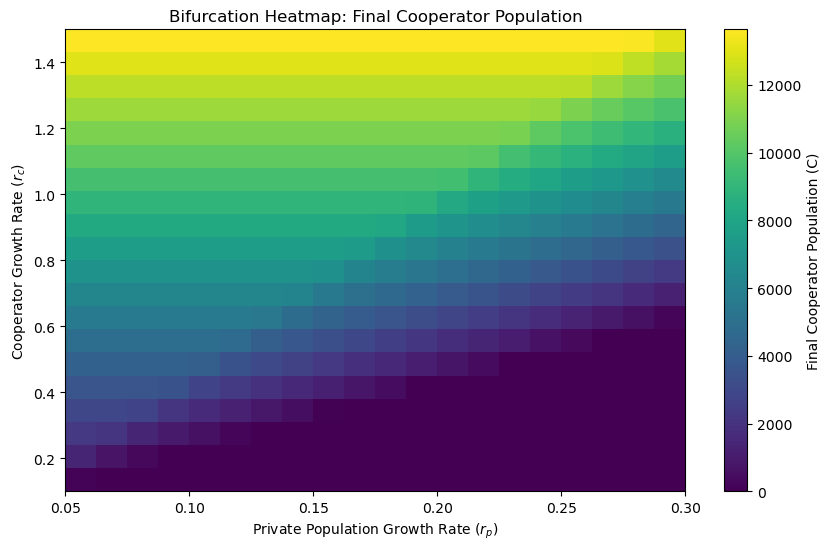

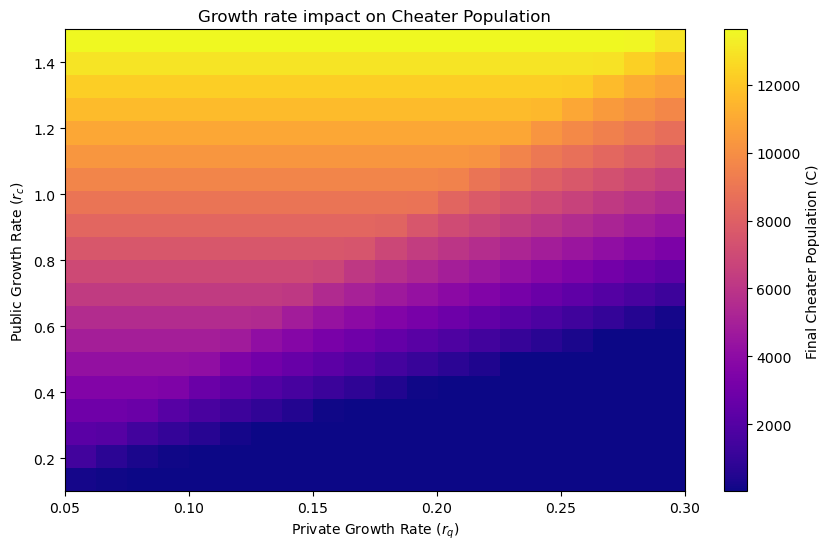

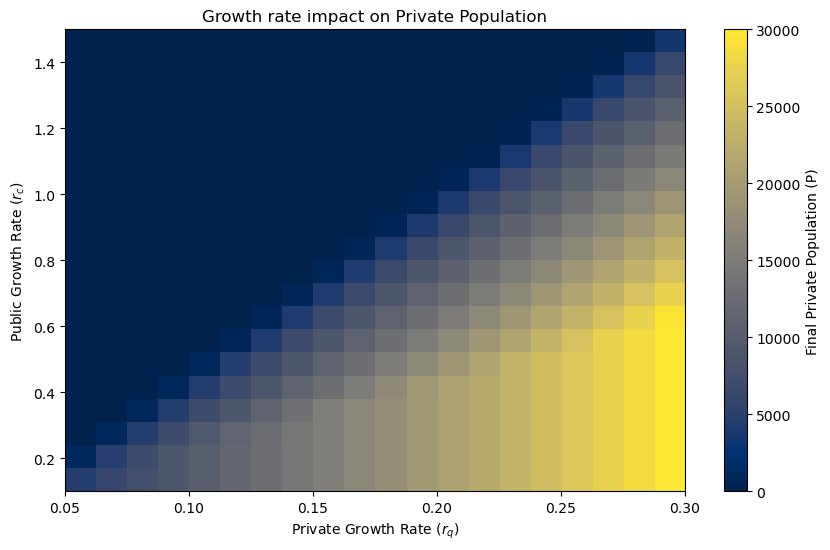

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (fixed except for r_c and r_p)
alpha = 0.0001  # Interaction between cooperators and defectors
beta = 0.00002  # Interaction between cooperators and private population
lambda_ = 0.00001  # Self-limiting term for cooperators
nu = 0.0001  # Self-limiting term for defectors
gamma = 0.00001  # Self-limiting term for private population

# Simulation parameters
T = 300  # Total simulation time
dt = 0.1  # Time step
n_steps = int(T / dt)
time = np.linspace(0, T, n_steps)

# Initial conditions
C0 = 100  # Initial population of cooperators
D0 = 10   # Initial population of defectors
P0 = 10   # Initial population of private population

# Range of r_c and r_p values to test
r_c_values = np.linspace(0.1, 1.5, 20)
r_p_values = np.linspace(0.05, 0.3, 20)

# Arrays to store final population sizes for each (r_c, r_p) combination
final_C = np.zeros((len(r_c_values), len(r_p_values)))
final_D = np.zeros((len(r_c_values), len(r_p_values)))
final_P = np.zeros((len(r_c_values), len(r_p_values)))

# Simulate for each combination of r_c and r_p
for i, r_c in enumerate(r_c_values):
    for j, r_p in enumerate(r_p_values):
        # Initialize populations for this simulation
        C = np.zeros(n_steps)
        D = np.zeros(n_steps)
        P = np.zeros(n_steps)
        C[0], D[0], P[0] = C0, D0, P0

        # Euler integration for population dynamics
        for t in range(1, n_steps):
            dC = (r_c * C[t-1] - alpha * C[t-1] * D[t-1] - beta * C[t-1] * P[t-1] - lambda_ * C[t-1]**2) * dt
            dD = (alpha * C[t-1] * D[t-1] - nu * D[t-1]**2) * dt
            dP = (r_p * P[t-1] - beta * P[t-1] * C[t-1] - gamma * P[t-1]**2) * dt

            # Update populations
            C[t] = max(C[t-1] + dC, 0)
            D[t] = max(D[t-1] + dD, 0)
            P[t] = max(P[t-1] + dP, 0)

        # Record final populations
        final_C[i, j] = C[-1]
        final_D[i, j] = D[-1]
        final_P[i, j] = P[-1]

# Plotting heatmap for final cooperators (C) as r_c and r_p vary
plt.figure(figsize=(10, 6))
plt.imshow(final_C, aspect='auto', origin='lower',
           extent=[r_p_values[0], r_p_values[-1], r_c_values[0], r_c_values[-1]],
           cmap='viridis')
plt.colorbar(label='Final Cooperator Population (C)')
plt.xlabel('Private Population Growth Rate ($r_p$)')
plt.ylabel('Cooperator Growth Rate ($r_c$)')
plt.title('Bifurcation Heatmap: Final Cooperator Population')
plt.show()

# Plotting heatmap for final defectors (D) as r_c and r_p vary
plt.figure(figsize=(10, 6))
plt.imshow(final_D, aspect='auto', origin='lower',
           extent=[r_p_values[0], r_p_values[-1], r_c_values[0], r_c_values[-1]],
           cmap='plasma')
plt.colorbar(label='Final Cheater Population (C)')
plt.xlabel('Private Growth Rate ($r_q$)')
plt.ylabel('Public Growth Rate ($r_c$)')
plt.title('Growth rate impact on Cheater Population')
plt.show()

# Plotting heatmap for final private population (P) as r_c and r_p vary
plt.figure(figsize=(10, 6))
plt.imshow(final_P, aspect='auto', origin='lower',
           extent=[r_p_values[0], r_p_values[-1], r_c_values[0], r_c_values[-1]],
           cmap='cividis')
plt.colorbar(label='Final Private Population (P)')
plt.xlabel('Private Growth Rate ($r_q$)')
plt.ylabel('Public Growth Rate ($r_c$)')
plt.title('Growth rate impact on Private Population')
plt.show()


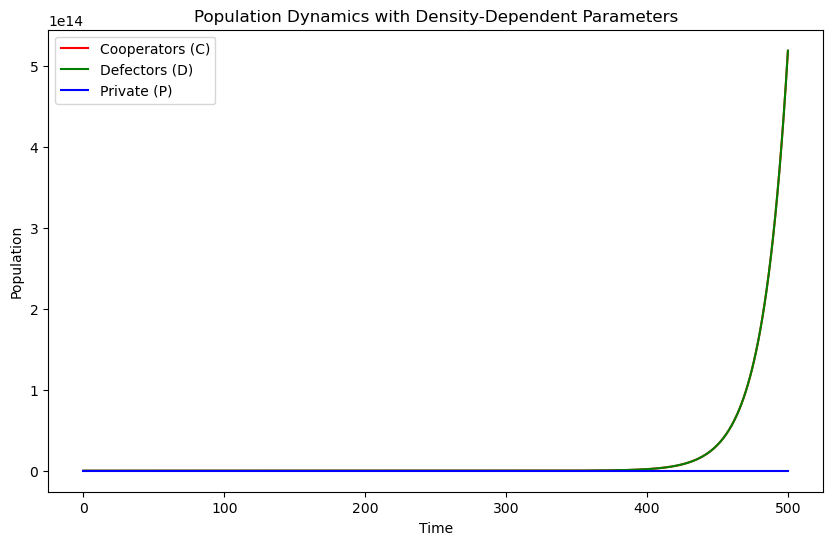

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the population dynamics model with density-dependent parameters
def population_dynamics(N, t, r_c, delta, K_alpha, nu, epsilon, K_beta, zeta, r_P, eta, K_C, K_P):
    C, D, P = N
    
    # Density-dependent interaction terms with carrying capacities
    alpha = (delta * D) / (K_alpha + D)
    beta = (epsilon * C) / (K_beta + C)
    beta1 = (epsilon * P) / (K_beta + P)
    lambda_C = (zeta * C) / (K_C + C)
    gamma_P = (eta * P) / (K_P + P)
    
    # Population dynamics equations
    dCdt = r_c * C - alpha * C  - beta1 * C  - lambda_C * C
    dDdt = alpha * C * D - nu * D**2
    dPdt = r_P * P - beta * P  - gamma_P * P
    
    return np.array([dCdt, dDdt, dPdt])

# Parameters
r_c = 0.08         # Growth rate of cooperators
delta = 0.01     # Maximum intensity of defector's impact on cooperators
K_alpha = 500      # Defector density at half-maximal effect on cooperators
nu = 0.01       # Defector cost
epsilon = 0.01   # Maximum intensity of cooperator's impact on private population
K_beta = 500      # Cooperator density at half-maximal effect on private population
zeta = 0.01     # Maximum intensity of cooperator self-limitation
r_P = 0.02        # Growth rate of private population
eta = 0.01    # Private population self-limitation

# Carrying capacities
K_C = 500         # Carrying capacity for cooperator self-limitation
K_P = 100         # Carrying capacity for private population self-limitation

# Initial conditions
C0, D0, P0 = 100.0, 10.0, 50.0  # Initial populations of C, D, P
initial_conditions = [C0, D0, P0]

# Time points for the simulation
time_points = np.linspace(0, 500, 1000)

# Solve the system of ODEs
solution = odeint(population_dynamics, initial_conditions, time_points, args=(r_c, delta, K_alpha, nu, epsilon, K_beta, zeta, r_P, eta, K_C, K_P))

# Extract the solutions
C_solution, D_solution, P_solution = solution.T

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, C_solution, 'r-', label='Cooperators (C)')
plt.plot(time_points, D_solution, 'g-', label='Defectors (D)')
plt.plot(time_points, P_solution, 'b-', label='Private (P)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Population Dynamics with Density-Dependent Parameters')
plt.legend()
plt.show()


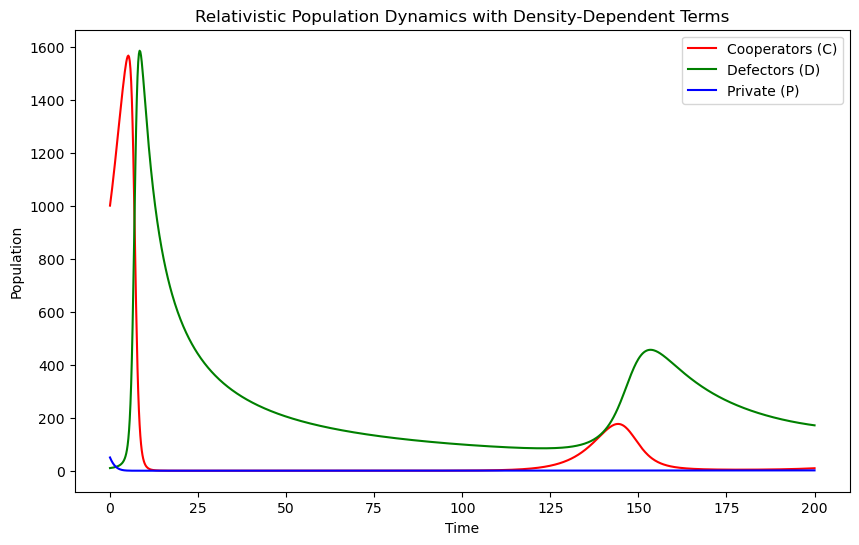

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Define the Lorentz factor function
def lorentz_factor(v, c=1):
    return 1 / np.sqrt(1 - (v/c)**2)

# Define the relativistic population dynamics model
def relativistic_population_dynamics(N, t, r_c, delta, K_alpha, nu, epsilon, K_beta, zeta, r_P, eta, K_C, K_P, v_C, v_D, v_P):
    C, D, P = N
    
    # Lorentz factors for each population
    gamma_C = lorentz_factor(v_C)
    gamma_D = lorentz_factor(v_D)
    gamma_P = lorentz_factor(v_P)
    gamma_CD = lorentz_factor(v_C - v_D)  # Relative velocity between C and D
    gamma_CP = lorentz_factor(v_C - v_P)  # Relative velocity between C and P
    
    # Density-dependent, relativistic interaction terms with carrying capacities
    alpha = delta * D / (K_alpha + gamma_CD * D)
    beta = epsilon * C / (K_beta + gamma_CP * C)
    lambda_C = zeta * C / (K_C + gamma_C * C)
    gamma_P_self = eta * P / (K_P + gamma_P * P)
    
    # Relativistic population dynamics equations
    dCdt = gamma_C * (r_c * C - alpha * C * D - beta * C * P - lambda_C * C**2)
    dDdt = gamma_D * (alpha * C * D - nu * D**2)
    dPdt = gamma_P * (r_P * P - beta * P * C - gamma_P_self * P**2)
    
    return np.array([dCdt, dDdt, dPdt])

# Parameters (these are hypothetical and can be adjusted)
r_c = 0.2
delta = 0.001
K_alpha = 50
nu = 0.0001
epsilon = 0.001
K_beta = 500
zeta = 0.0001
r_P = 0.02
eta = 0.000001
K_C = 500
K_P = 100

# Velocities for relativistic effects (as a fraction of light speed)
v_C = 0.2
v_D = 0.3
v_P = 0.1

# Initial conditions
C0, D0, P0 = 1000.0, 10.0, 50.0
initial_conditions = [C0, D0, P0]

# Time points
time_points = np.linspace(0, 200, 1000)

# Solve the system of ODEs
solution = odeint(relativistic_population_dynamics, initial_conditions, time_points,
                  args=(r_c, delta, K_alpha, nu, epsilon, K_beta, zeta, r_P, eta, K_C, K_P, v_C, v_D, v_P))

# Extract the solutions
C_solution, D_solution, P_solution = solution.T

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_points, C_solution, 'r-', label='Cooperators (C)')
plt.plot(time_points, D_solution, 'g-', label='Defectors (D)')
plt.plot(time_points, P_solution, 'b-', label='Private (P)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Relativistic Population Dynamics with Density-Dependent Terms')
plt.legend()
plt.show()


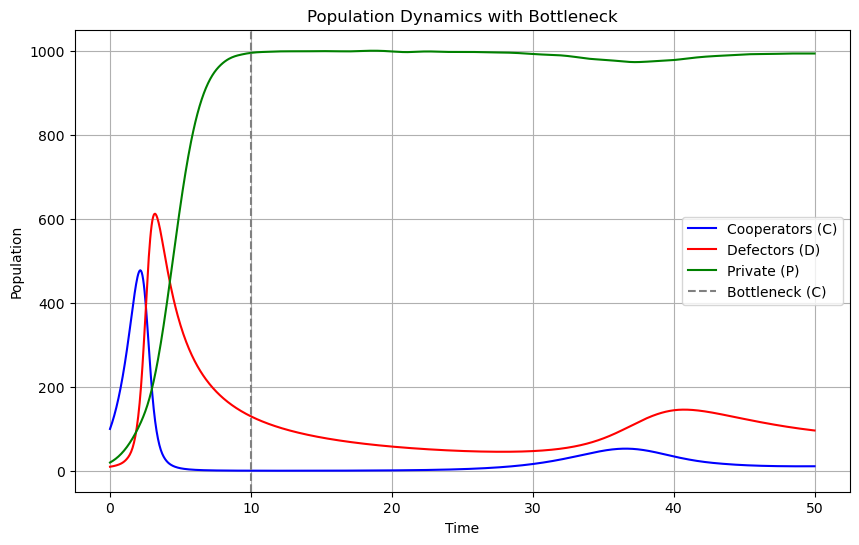

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the system of ODEs
def population_dynamics(t, y, params):
    C, D, P = y
    r_c, r_p, alpha, beta, lambda_, nu, gamma = params

    dCdt = r_c * C - alpha * C * D - beta * C * P - lambda_ * C**2
    dDdt = alpha * C * D - nu * D**2
    dPdt = r_p * P - beta * P * C - gamma * P**2

    return [dCdt, dDdt, dPdt]

# Parameters
params = {
    "r_c": 1.0,  # Growth rate of cooperators
    "r_p": 1.0,  # Growth rate of private population
    "alpha": 0.005,  # Benefit shared with defectors
    "beta": 0.0005,  # Competition between public and private
    "lambda_": 0.0001,  # Self-limitation of cooperators
    "nu": 0.001,  # Self-limitation of defectors
    "gamma": 0.001,  # Self-limitation of private population
}

# Initial conditions
C0, D0, P0 = 100, 10, 20  # Initial populations
y0 = [C0, D0, P0]

# Time span
t_span = (0, 50)  # Start and end time
t_eval = np.linspace(*t_span, 1000)  # Time points for evaluation

# Function to introduce a bottleneck
def bottleneck(t, y, params, bottleneck_time, reduction_factor):
    if abs(t - bottleneck_time) < 1e-3:  # Apply bottleneck at a specific time
        y[0] *= reduction_factor  # Apply reduction to C
    return population_dynamics(t, y, params)

# Solve the system numerically
def solve_with_bottleneck():
    bottleneck_time = 30  # Time at which bottleneck occurs
    reduction_factor = 0.2  # Fraction of the population retained after bottleneck

    def dynamics_with_bottleneck(t, y):
        return bottleneck(t, y, list(params.values()), bottleneck_time, reduction_factor)

    solution = solve_ivp(
        dynamics_with_bottleneck,
        t_span,
        y0,
        t_eval=t_eval,
        method="RK45",
    )
    return solution

# Simulate
solution = solve_with_bottleneck()

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], label="Cooperators (C)", color="blue")
plt.plot(solution.t, solution.y[1], label="Defectors (D)", color="red")
plt.plot(solution.t, solution.y[2], label="Private (P)", color="green")
plt.axvline(x=10, color="gray", linestyle="--", label="Bottleneck (C)")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Population Dynamics with Bottleneck")
plt.legend()
plt.grid()
plt.show()
